# Tugas Besar 1 IF3270 Pembelajaran Mesin
**Nama Anggota:**

1. Nicholas Andhika Lucas (13523014)
2. Stefan Mattew Susanto (13523020)
3. Kenneth Ricardo Chandra (13523022)


**Kelas:** K1

# Daftar Isi
- [0. Import Libraries & Load Data](#0-import-libraries--load-data)
- [1. Exploratory Data Analysis (EDA)](#1-exploratory-data-analysis-eda)
  - [1.1. Gambaran Umum Dataset](#11-gambaran-umum-dataset)
  - [1.2. Visualisasi Data](#12-visualisasi-data)
- [2. Data Cleaning and Preprocessing](#2-data-cleaning-and-preprocessing)
  - [2.1. Outlier Handling](#21-outlier-handling)
  - [2.2. Handling Missing Values](#22-handling-missing-values)
  - [2.3. Encoding Fitur Kategorik](#23-encoding-fitur-kategorik)
  - [2.4. Feature Scaling](#24-feature-scaling)
  - [2.5. Feature Engineering](#25-feature-engineering)
  - [2.6. Train Validation Split](#26-train-validation-split)
- [3. Pengujian Model FFNN](#3-pengujian-model-ffnn)
  - [3.1. Hyperparameter](#31-hyperparameter)
    - [3.1.1. Pengaruh depth (banyak layer) dan width (banyak neuron per layer)](#311-pengaruh-depth-banyak-layer-dan-width-banyak-neuron-per-layer)
    - [3.1.2. Pengaruh fungsi aktivasi hidden layer](#312-pengaruh-fungsi-aktivasi-hidden-layer)
    - [3.1.3. Pengaruh learning rate](#313-pengaruh-learning-rate)
    - [3.1.4. Pengaruh inisialisasi bobot](#314-pengaruh-inisialisasi-bobot)
  - [3.2. Pengaruh Regularisasi](#32-pengaruh-regularisasi)
  - [3.3. Uji Perbandingan](#33-uji-perbandingan)
  - [3.4. Visualisasi Pengujian](#34-visualisasi-pengujian)
    - [3.4.1. Grafik Pengaruh Depth dan Width](#341-grafik-pengaruh-depth-dan-width)
    - [3.4.2. Grafik Pengaruh Fungsi Aktivasi Hidden Layer](#342-grafik-pengaruh-fungsi-aktivasi-hidden-layer)
    - [3.4.3. Grafik Pengaruh Learning Rate](#343-grafik-pengaruh-learning-rate)
    - [3.4.4. Grafik Pengaruh Inisialisasi Bobot](#344-grafik-pengaruh-inisialisasi-bobot)
    - [3.4.5. Grafik Pengaruh Regularisasi](#345-grafik-pengaruh-regularisasi)
  - [3.5. Eskperimen Normalisasi RMS](#35-eksperimen-normalisasi-rms)  

## 0. Import Libraries & Load Data
[Back to Daftar Isi](#daftar-isi)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier
)

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

from ffnn import FFNN, Layer

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
# Load dataset

df = pd.read_csv('datasetml_2026.csv')

print("Dataset shape:", df.shape)

Dataset shape: (10000, 12)


## 1. Exploratory Data Analysis (EDA)
[Back to Daftar Isi](#daftar-isi)

### 1.1 Gambaran Umum Dataset
[Back to Daftar Isi](#daftar-isi)

In [3]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
df.tail()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
9995,8.040882,0,Tier 3,USA,100-300,2,98.120449,80.866213,Data Science,Manufacturing,6.298524,Placed
9996,5.401324,3,Tier 1,UK,100-300,1,68.622854,83.458035,Data Science,Consulting,7.352717,Not Placed
9997,6.435747,0,Tier 3,UK,300+,2,69.067773,50.992745,Core CS,Other,3.871205,Placed
9998,7.396612,1,Tier 3,Germany,100-300,3,45.050463,86.807882,Cloud,Finance,3.687731,Placed
9999,7.515511,3,Tier 2,UK,300+,4,66.947232,46.385843,AI/ML,Manufacturing,4.181389,Placed


In [5]:
df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [7]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [8]:
# Cek duplicate values
duplicate = df.duplicated().sum()
duplicate_pct = (duplicate / len(df) * 100).round(2)
pd.DataFrame({'Duplicate Count': [duplicate], 'Duplicate (%)': [duplicate_pct]})

,Duplicate Count,Duplicate (%)
0,0,0.0


In [9]:
# Cek object values
for i in df.select_dtypes(include='object').columns:
    print(df[i].value_counts())
    print("***" * 10)

college_tier
Tier 2    3993
Tier 1    3034
Tier 3    2973
Name: count, dtype: int64
******************************
country
Germany    2057
USA        2040
India      1985
Canada     1976
UK         1942
Name: count, dtype: int64
******************************
university_ranking_band
300+       4075
100-300    3975
Top 100    1950
Name: count, dtype: int64
******************************
specialization
Data Science     2036
Core CS          2007
Cybersecurity    1992
AI/ML            1991
Cloud            1974
Name: count, dtype: int64
******************************
industry
Consulting       1739
Healthcare       1680
Manufacturing    1673
Tech             1643
Finance          1635
Other            1630
Name: count, dtype: int64
******************************
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
******************************


### 1.2 Visualisasi Data
[Back to Daftar Isi](#daftar-isi)

In [10]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

#### Distribusi kelas tiap feature kategorikal
Visualisasi menunjukkan distribusi data relatif seimbang.

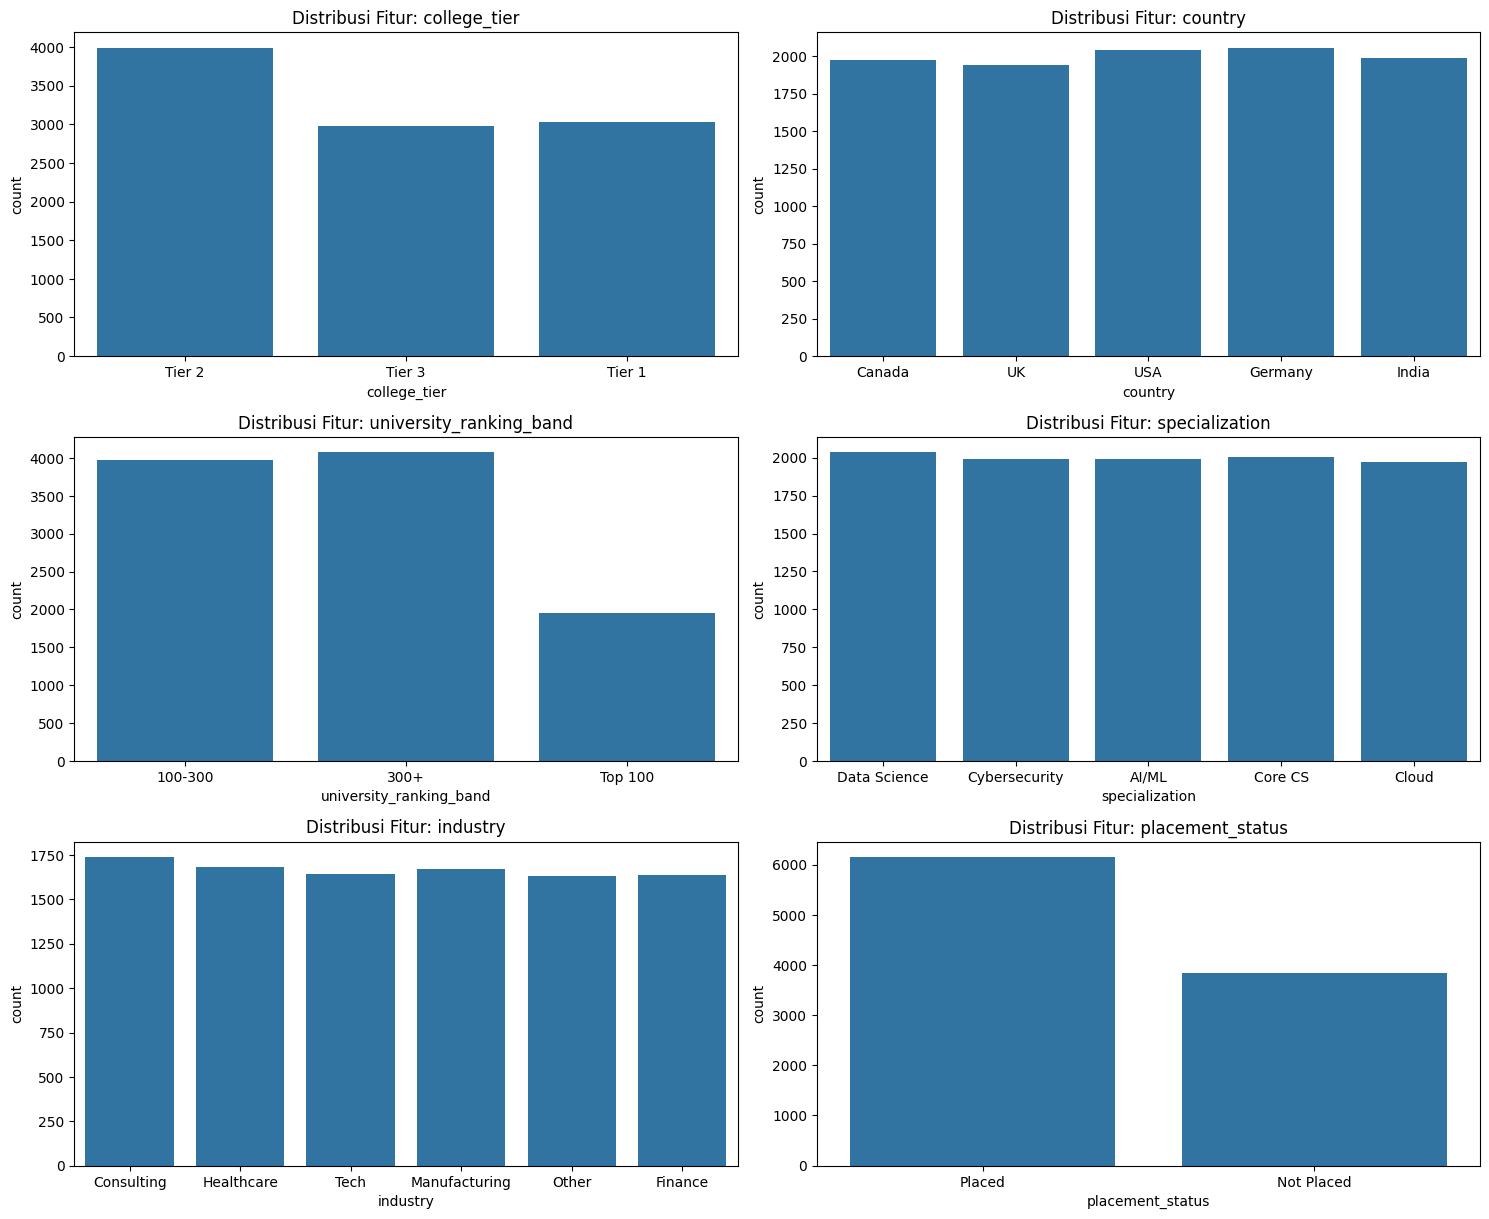

In [11]:
plt.figure(figsize=(15, len(cat_cols) * 4))
for i, col in enumerate(cat_cols):
    plt.subplot(len(cat_cols), 2, i + 1)
    sns.countplot(data=df, x=col)
    plt.xticks()
    plt.title(f'Distribusi Fitur: {col}')
plt.tight_layout()
plt.show()

#### Distribusi feature dan outlier feature numerik
Distribusi fitur relatif normal dengan skewness kecil, kecuali untuk backlogs dan internship_count, sehingga dapat melakukan transformasi. Pada kelas tersebut juga dapat mempertimbangkan untuk menggabungkan kelas dengan frekuensi yang sedikit menjadi 1 kelompok.

Untuk handling outlier, akan dipertimbangkan melakukan capping berdasarkan frekuensi outliernya.

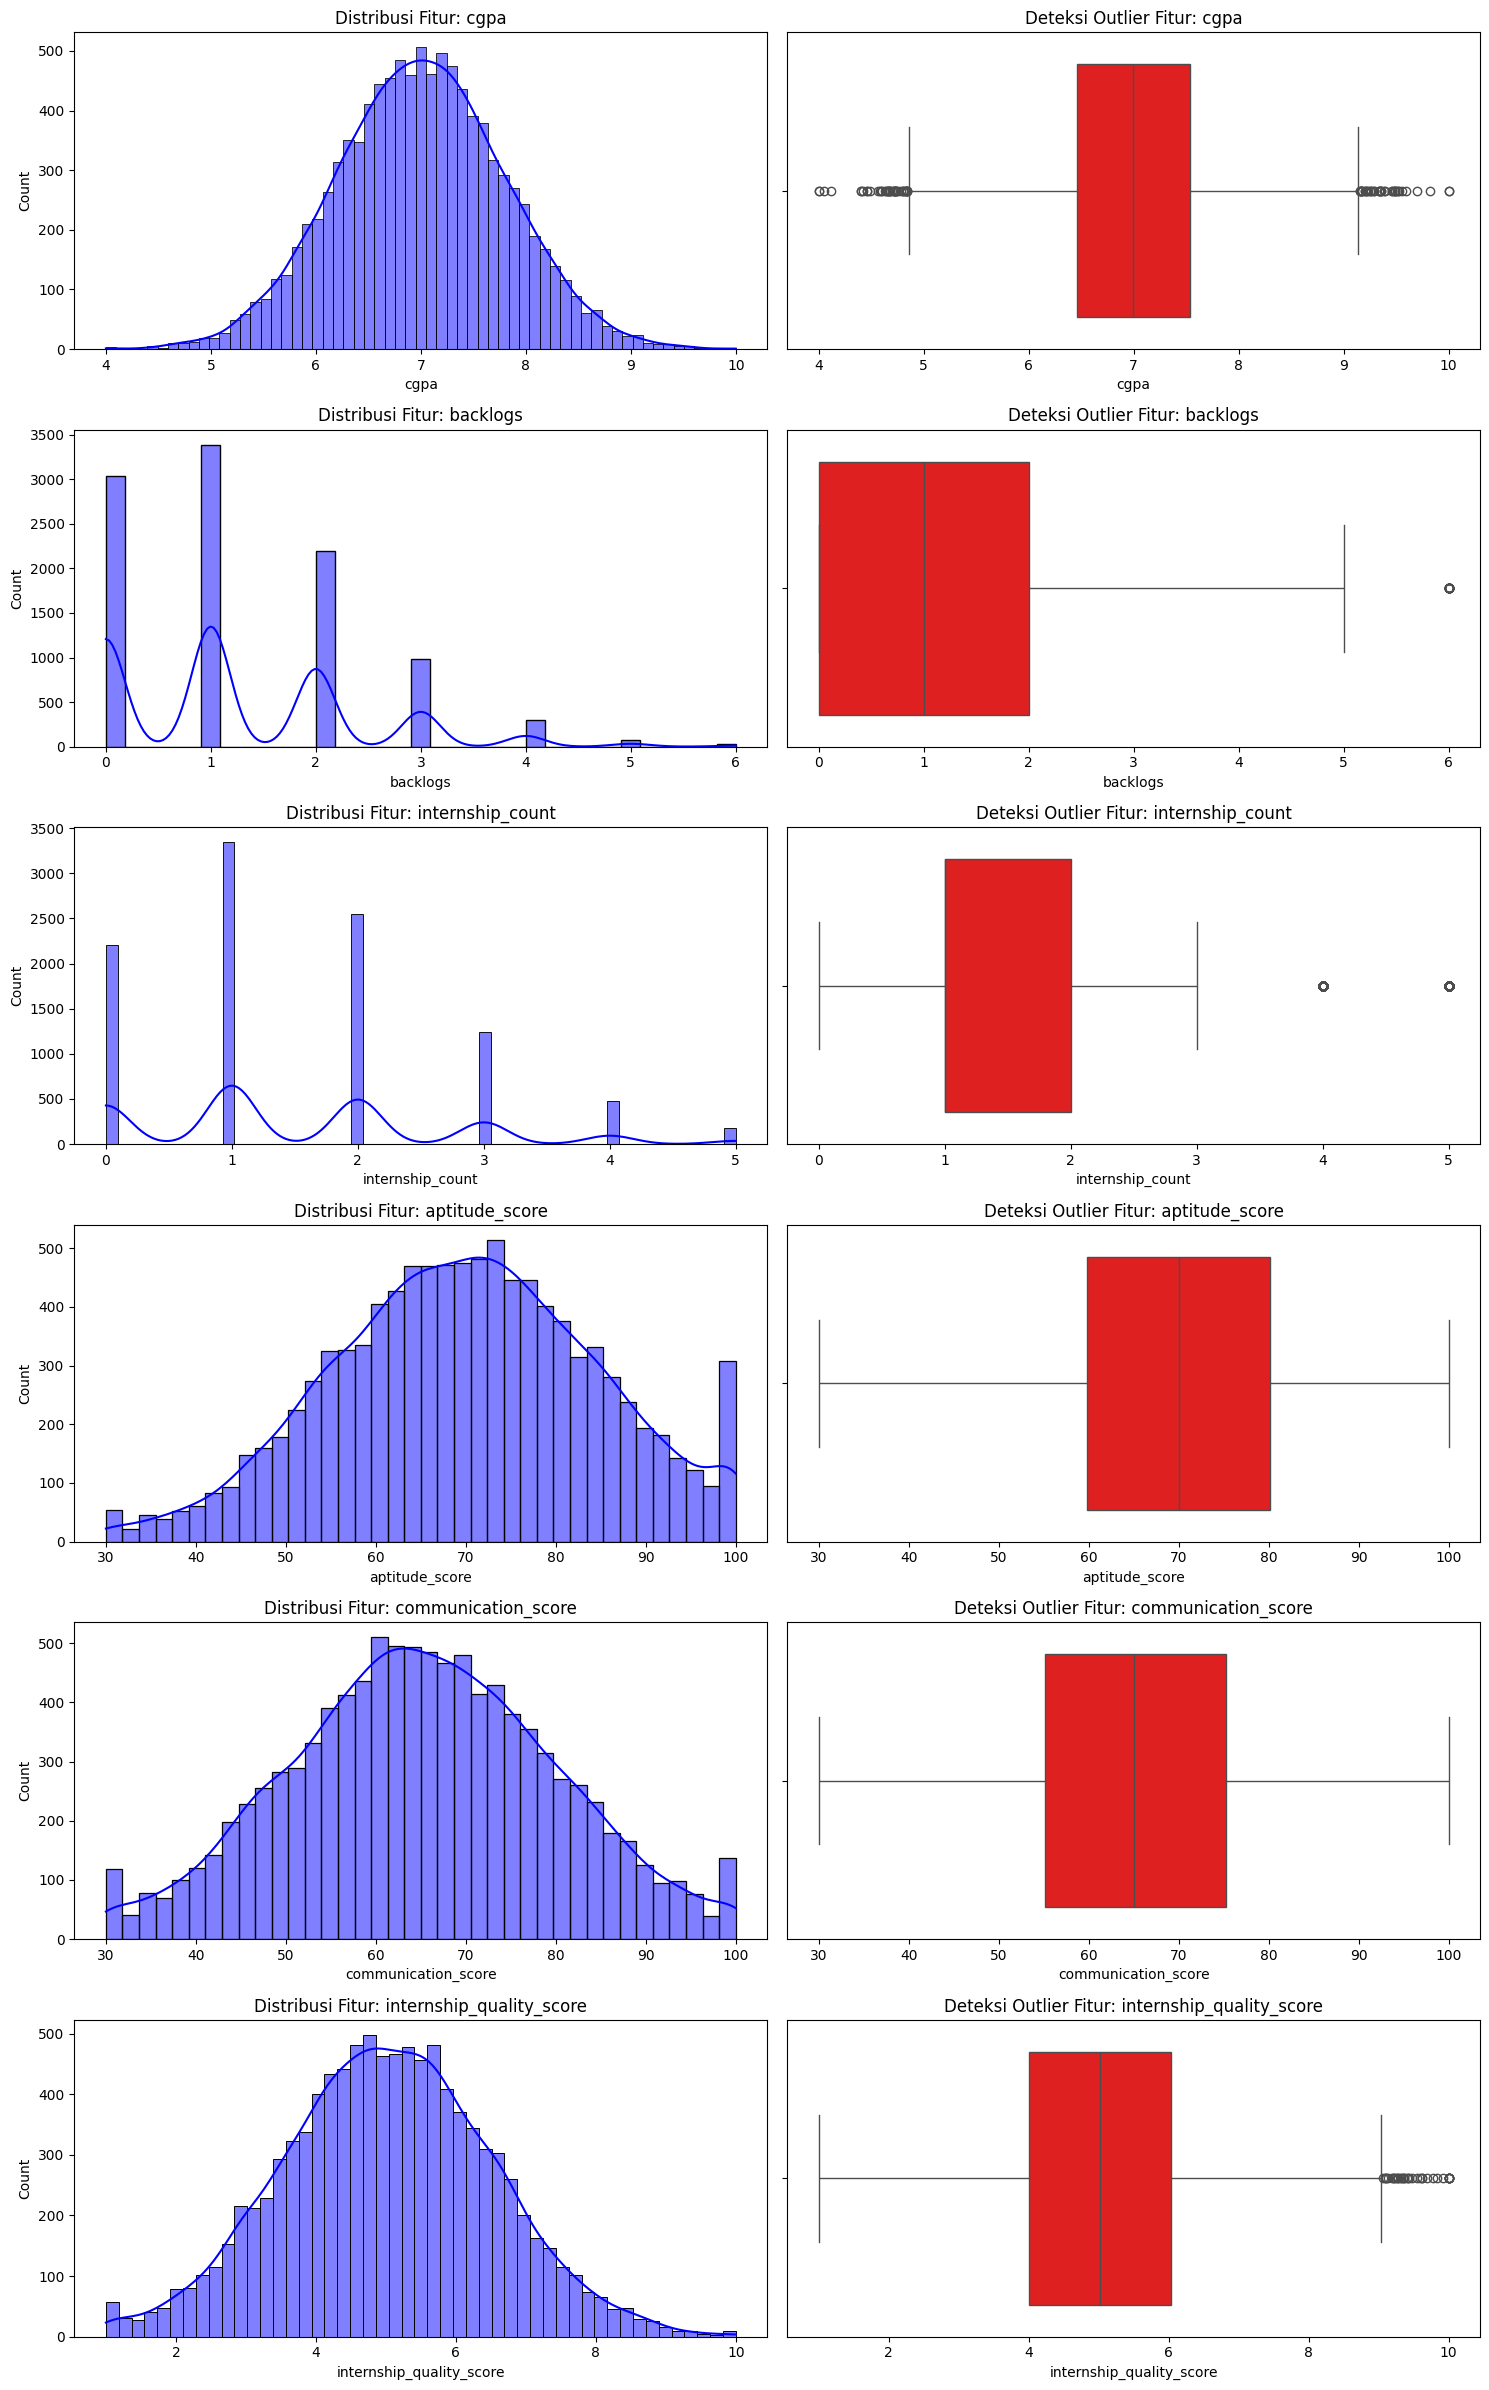

In [12]:
plt.figure(figsize=(15, len(num_cols) * 4))
for i, col in enumerate(num_cols):

    plt.subplot(len(num_cols), 2, 2 * i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribusi Fitur: {col}')

    plt.subplot(len(num_cols), 2, 2 * i + 2)
    sns.boxplot(x=df[col], color='red')
    plt.title(f'Deteksi Outlier Fitur: {col}')
    
plt.tight_layout()
plt.show()

#### Korelasi antar feature numerik
Tidak ada feature numerik yang saling memiliki korelasi yang kuat, tidak perlu drop column. Untuk tahap selanjutnya, akan dicek korelasi feature dengan target class setelah di-encoding.

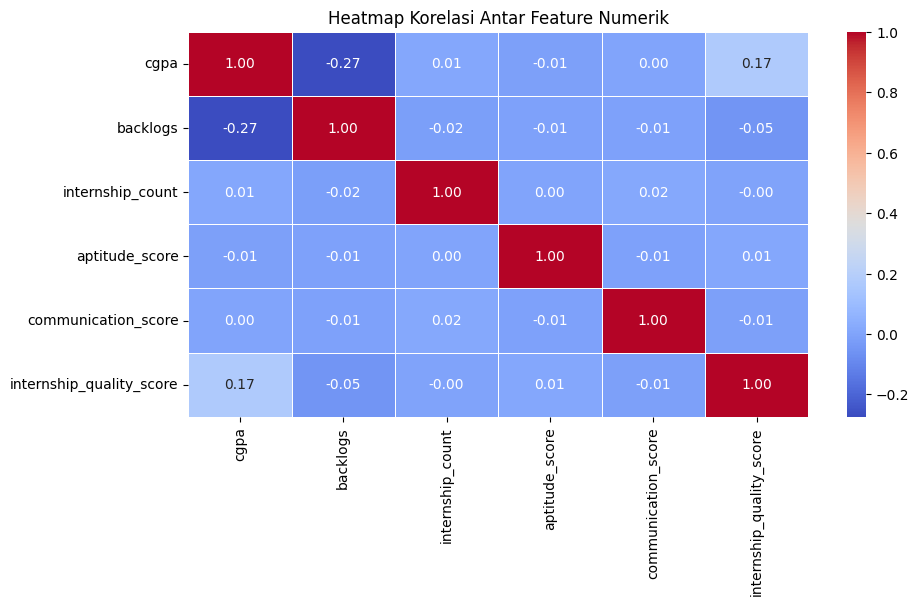

In [13]:
plt.figure(figsize=(10, 5))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Feature Numerik')
plt.show()

#### Persebaran Feature Kategorikal terhadap Placement Status
Feature kategorikal relatif mempertahankan distribusi yang sama dari target column kecuali university_ranking_band yang memiliki distribusi yang berbeda. Hal ini berarti ada kemungkinan korelasi feature ini yang kuat terhadap target.

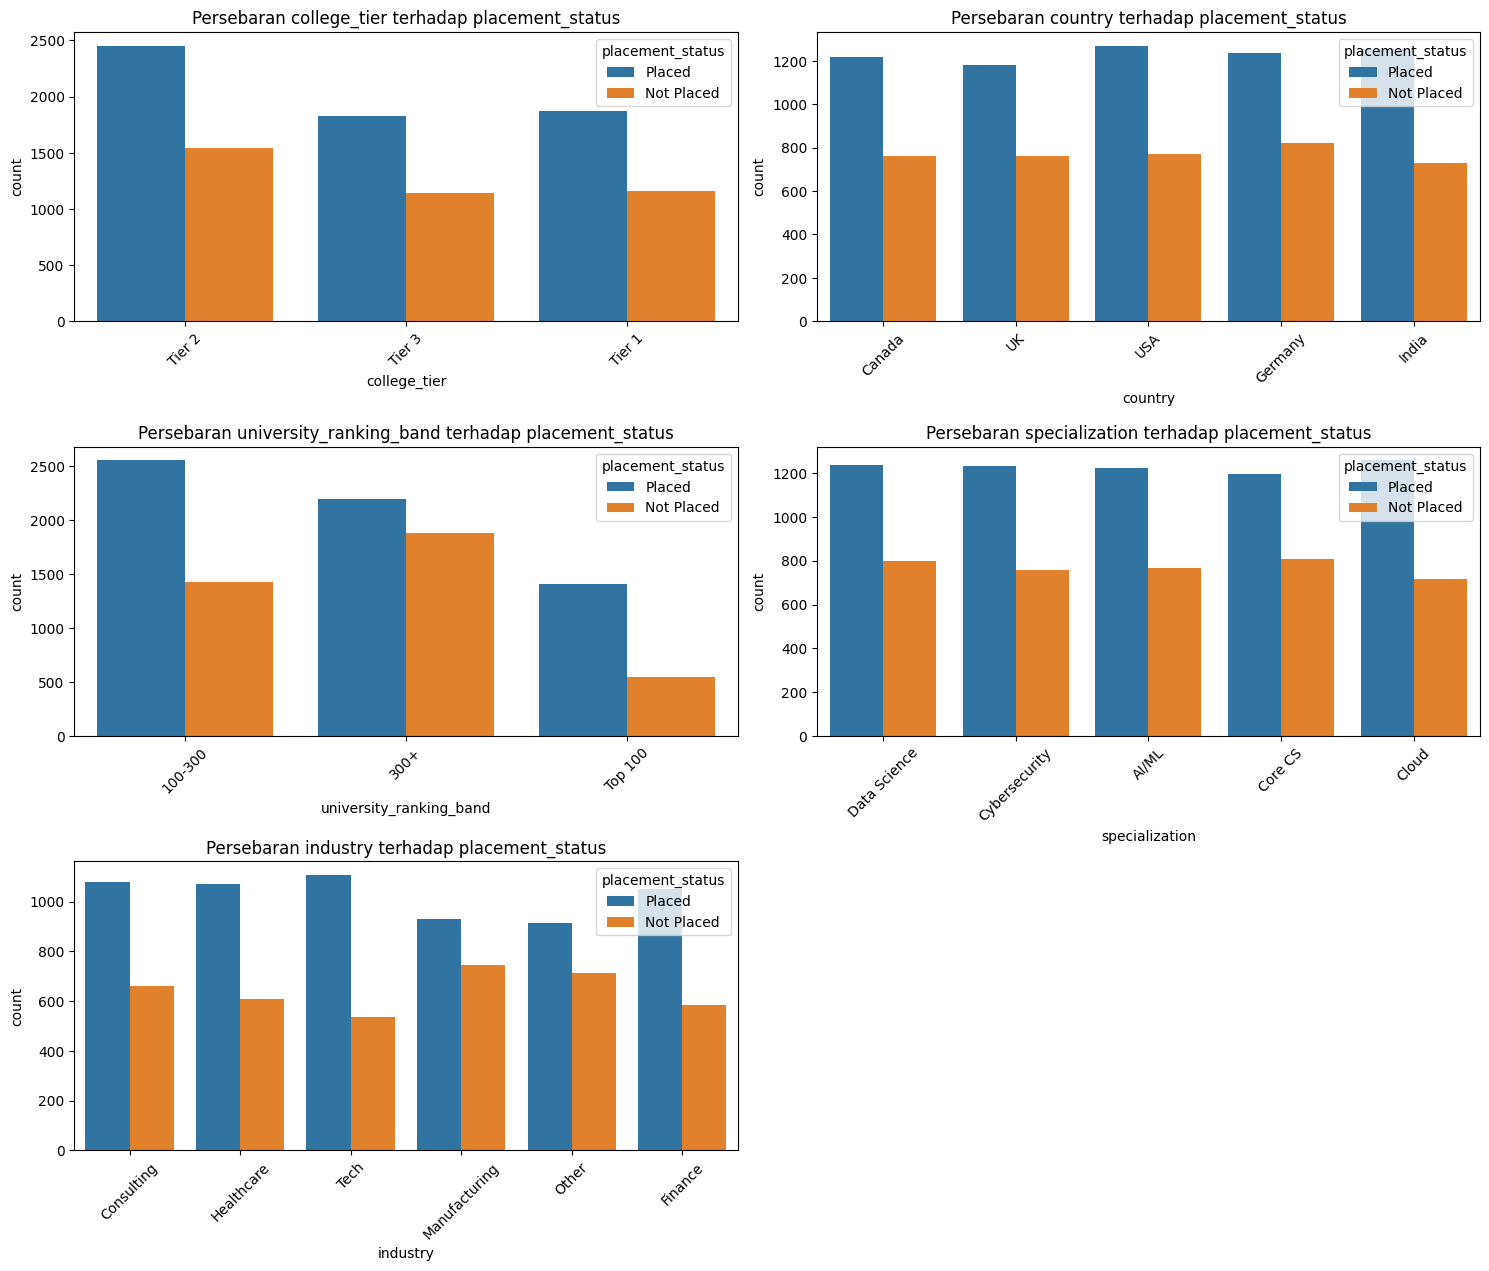

In [14]:
target_col = [col for col in df.columns if 'placement_status' in col.lower()]
target = target_col[0] if target_col else None

if target and len(cat_cols) > 0:
    cat_features = [col for col in cat_cols if col != target]
    plt.figure(figsize=(15, len(cat_features) * 4))
    for i, col in enumerate(cat_features):
        plt.subplot(len(cat_features), 2, i + 1)
        sns.countplot(data=df, x=col, hue=target)
        plt.title(f'Persebaran {col} terhadap {target}')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Kolom target status atau fitur kategorikal tidak ditemukan.")

## 2. Data Cleaning and Preprocessing
[Back to Daftar Isi](#daftar-isi)

In [15]:
TARGET_COL = 'placement_status'
CAT_COLS = [c for c in df.select_dtypes(include='object').columns if c != TARGET_COL]
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [TARGET_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

train = df.copy()
test  = df.copy()

Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


### 2.1 Outlier Handling
[Back to Daftar Isi](#daftar-isi)

In [16]:
def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in NUM_COLS:
    lower, upper = get_iqr_bounds(train[col])
    n = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_percent = n / len(train) * 100
    print(f"{col}: {n} outliers ({outlier_percent:.2f}%)")

    train[col] = np.clip(train[col], lower, upper)

print("\nApplied outlier clipping\n")
train.describe()

cgpa: 83 outliers (0.83%)
backlogs: 29 outliers (0.29%)
internship_count: 662 outliers (6.62%)
aptitude_score: 0 outliers (0.00%)
communication_score: 0 outliers (0.00%)
internship_quality_score: 36 outliers (0.36%)

Applied outlier clipping



,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.998320,1.245200,1.447900,69.877531,65.158600,5.019825
std,0.796826,1.139125,1.088786,14.700532,14.740446,1.501286
min,4.849522,0.000000,0.000000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.000000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.000000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.000000,80.213934,75.277248,6.031400
max,9.149270,5.000000,3.500000,100.000000,100.000000,9.059517


### 2.2 Handling Missing Values
[Back to Daftar Isi](#daftar-isi)

In [17]:
# Tidak dilakukan handling missing values atau duplicates, 
# karena tidak ditemukan saat EDA

### 2.3 Encoding Fitur Kategorik
[Back to Daftar Isi](#daftar-isi)

In [18]:
le_cols = ['college_tier', 'university_ranking_band'] # ordinal features
ohe_cols = ['country', 'specialization', 'industry'] # nominal features

# Label Encoding untuk fitur ordinal
le = LabelEncoder()
for col in le_cols:
    le.fit(train[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    print(f"Applied Label Encoding to {col}")

# OHE untuk fitur nominal
train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
test  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)
# Sejajarkan kolom test agar tidak ada kolom yang hilang
feat_cols = [c for c in train.columns if c not in [TARGET_COL]]
test = test.reindex(columns=feat_cols, fill_value=0)
print("\nApplied One Hot Encoding\n")

print("Final feature columns:", feat_cols)

Applied Label Encoding to college_tier
Applied Label Encoding to university_ranking_band

Applied One Hot Encoding

Final feature columns: ['cgpa', 'backlogs', 'college_tier', 'university_ranking_band', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'specialization_Cloud', 'specialization_Core CS', 'specialization_Cybersecurity', 'specialization_Data Science', 'industry_Finance', 'industry_Healthcare', 'industry_Manufacturing', 'industry_Other', 'industry_Tech']


### 2.4 Feature Scaling
[Back to Daftar Isi](#daftar-isi)

In [19]:
scaler = StandardScaler()
train[NUM_COLS] = scaler.fit_transform(train[NUM_COLS])
test[NUM_COLS]  = scaler.transform(test[NUM_COLS])

### 2.5 Feature Engineering
[Back to Daftar Isi](#daftar-isi)

In [20]:
# 1. *** FEATURE BINNING ***
# for i in train[NUM_COLS].columns:
#     print(df[i].value_counts())
#     print("***" * 10)

# Apply binning to backlogs and internship_count
# 1. Binning Backlogs (0, 1, 2, dan 3-6 digabung)
print("Applying Binning")
train['backlogs'] = pd.cut(df['backlogs'], 
                               bins=[-1, 0, 1, 2, 6], 
                               labels=['0', '1', '2', '3'])

test['backlogs'] = pd.cut(df['backlogs'], 
                               bins=[-1, 0, 1, 2, 6], 
                               labels=['0', '1', '2', '3'])

# 2. Binning Internship Count (0, 1, 2, dan 3-5 digabung)
train['internship_count'] = pd.cut(df['internship_count'], 
                                 bins=[-1, 0, 1, 2, 5], 
                                 labels=['0', '1', '2', '3'])

test['internship_count'] = pd.cut(df['internship_count'], 
                                 bins=[-1, 0, 1, 2, 5], 
                                 labels=['0', '1', '2', '3'])

print("Distribusi Binning Backlogs:")
print(train['backlogs'].value_counts())
print("\nDistribusi Binning Internship Count:")
print(train['internship_count'].value_counts())

le_bin = LabelEncoder()
train['backlogs'] = le_bin.fit_transform(train['backlogs'].astype(str))
test['backlogs'] = le_bin.transform(test['backlogs'].astype(str))

Applying Binning
Distribusi Binning Backlogs:
backlogs
1    3387
0    3033
2    2191
3    1389
Name: count, dtype: int64

Distribusi Binning Internship Count:
internship_count
1    3342
2    2547
0    2207
3    1904
Name: count, dtype: int64


In [21]:
# 2. *** FEATURE CORRELATION ***
# Analisis korelasi antar semua feature dengan target

le_target = LabelEncoder()
target_encoded = le_target.fit_transform(train[TARGET_COL].astype(str))
features_to_check = train.drop(columns=[TARGET_COL])
numeric_features = features_to_check.select_dtypes(include=[np.number])

correlations = numeric_features.corrwith(pd.Series(target_encoded, index=train.index))
correlations_pct = (correlations * 100).round(2).sort_values(ascending=False)

print("Korelasi Feature terhadap Target\n")
for feature, corr_val in correlations_pct.items():
    print(f"{feature:<35} : {corr_val:>6.2f}%")

# Drop college tier
train.drop(columns=['college_tier'], inplace=True)
test.drop(columns=['college_tier'], inplace=True)
print("\nDropped 'college_tier'\n")


Korelasi Feature terhadap Target

cgpa                                :  33.28%
internship_quality_score            :  21.46%
communication_score                 :   9.64%
aptitude_score                      :   9.04%
university_ranking_band             :   2.71%
college_tier                        :  -0.20%
backlogs                            : -36.35%

Dropped 'college_tier'



### 2.6 Train Validation Split
[Back to Daftar Isi](#daftar-isi)

In [22]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL]]

X            = train[feature_cols]
y            = train[TARGET_COL]
X_test_final = test[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,          
    random_state=RANDOM_STATE,
    stratify=train['placement_status'] # pertimbangkan stratify=y jika kelas imbalanced
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (8000, 20) | y_train: (8000,)
X_val:   (2000, 20) | y_val:   (2000,)


## 3. Pengujian Model FFNN
[Back to Daftar Isi](#daftar-isi)

In [23]:
def train_and_evaluate_ffnn(model, X_train, y_train, X_val, y_val, model_name="FFNN Model", 
                            epochs=100, learning_rate=0.05, batch_size=32, l1_lambda=0.0, l2_lambda=0.0, verbose=0):
    print(f"Training {model_name}...")
    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val, batch_size=batch_size, learning_rate=learning_rate, epochs=epochs, l1_lambda=l1_lambda, l2_lambda=l2_lambda, verbose=verbose)
    
    y_val_pred = (model.forward(X_val) > 0.5).astype(int)
    
    print(f"{'='*55}")
    print(f"  {model_name} - Data Validation")
    print(f"{'='*55}")
    
    macro_f1 = f1_score(y_val, y_val_pred, average='macro')
    print(f">>> Validation Macro F1-Score: {macro_f1:.4f}\n")
    
    return history, macro_f1

In [24]:
# Ubah tipe data ke float 
X_train_np = X_train.astype(float).values
X_val_np = X_val.astype(float).values
input_dim = X_train_np.shape[1]

# Encode target dan pastikan dimensinya (-1, 1) agar sesuai dengan output matriks model (n, 1)
le = LabelEncoder()
y_train = le.fit_transform(y_train.astype(str)).reshape(-1, 1).astype(float)
y_val = le.transform(y_val.astype(str)).reshape(-1, 1).astype(float)

# *** BASE MODEL ***
# *** 3 hidden layer dengan 8 neuron ***
ffnn_base_model = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_base_model.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='uniform'))
ffnn_base_model.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_base_model.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_base_model.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

In [25]:
# Base model
history_base, f1_base = train_and_evaluate_ffnn(
    model=ffnn_base_model,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Base Model",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

Training FFNN Base Model...
  FFNN Base Model - Data Validation
>>> Validation Macro F1-Score: 0.7287



### 3.1 Hyperparameter
[Back to Daftar Isi](#daftar-isi)

#### 3.1.1 Pengaruh depth (banyak layer) dan width (banyak neuron per layer)
[Back to Daftar Isi](#daftar-isi)

- Base model dengan 3 hidden layer dengan 8 neuron
- 3 variasi kombinasi width (depth tetap): 2, 4, 5 hidden layer
- 3 variasi depth (width semua layer tetap): 16, 24, 32

In [26]:
# *** VARIASI DEPTH ***
# Depth 1: 2 hidden layer
ffnn_depth_1 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_depth_1.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_1.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Depth 2: 4 hidden layer
ffnn_depth_2 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_depth_2.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_2.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Depth 3: 5 hidden layer
ffnn_depth_3 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_depth_3.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_depth_3.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

In [27]:
# *** VARIASI WIDTH ***
# Width 1: 4 neuron per layer
ffnn_width_1 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_width_1.add_layer(Layer(input_size=input_dim, output_size=4, activation='relu', init_method='uniform'))
ffnn_width_1.add_layer(Layer(input_size=4, output_size=4, activation='relu', init_method='uniform'))
ffnn_width_1.add_layer(Layer(input_size=4, output_size=1, activation='sigmoid', init_method='uniform'))

# Width 2: 16 neuron per layer
ffnn_width_2 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_width_2.add_layer(Layer(input_size=input_dim, output_size=16, activation='relu', init_method='uniform'))
ffnn_width_2.add_layer(Layer(input_size=16, output_size=16, activation='relu', init_method='uniform'))
ffnn_width_2.add_layer(Layer(input_size=16, output_size=1, activation='sigmoid', init_method='uniform'))

# Width 3: 32 neuron per layer
ffnn_width_3 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_width_3.add_layer(Layer(input_size=input_dim, output_size=32, activation='relu', init_method='uniform'))
ffnn_width_3.add_layer(Layer(input_size=32, output_size=32, activation='relu', init_method='uniform'))
ffnn_width_3.add_layer(Layer(input_size=32, output_size=1, activation='sigmoid', init_method='uniform'))

In [28]:
# *** VARIASI DEPTH ***
# Base Model
print(f"{'='*55}")
print(f"  FFNN Base Model (3 Hidden Layer) - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# Depth 1: 2 Hidden Layer
history_depth1, f1_depth1 = train_and_evaluate_ffnn(
    model=ffnn_depth_1,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Depth 1 (2 Hidden Layer)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Depth 2: 4 Hidden Layer
history_depth2, f1_depth2 = train_and_evaluate_ffnn(
    model=ffnn_depth_2,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Depth 2 (4 Hidden Layer)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Depth 3: 5 Hidden Layer
history_depth3, f1_depth3 = train_and_evaluate_ffnn(
    model=ffnn_depth_3,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Depth 3 (5 Hidden Layer)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

  FFNN Base Model (3 Hidden Layer) - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287

Training FFNN Depth 1 (2 Hidden Layer)...
  FFNN Depth 1 (2 Hidden Layer) - Data Validation
>>> Validation Macro F1-Score: 0.7235

Training FFNN Depth 2 (4 Hidden Layer)...
  FFNN Depth 2 (4 Hidden Layer) - Data Validation
>>> Validation Macro F1-Score: 0.7348

Training FFNN Depth 3 (5 Hidden Layer)...
  FFNN Depth 3 (5 Hidden Layer) - Data Validation
>>> Validation Macro F1-Score: 0.7353



In [29]:
# *** VARIASI WIDTH ***
# Base Model
print(f"{'='*55}")
print(f"  FFNN Base Model (8 Neuron) - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# Width 1: 16 Neuron
history_width1, f1_width1 = train_and_evaluate_ffnn(
    model=ffnn_width_1,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Width 1 (4 Neuron)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Width 2: 32 Neuron
history_width2, f1_width2 = train_and_evaluate_ffnn(
    model=ffnn_width_2,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Width 2 (16 Neuron)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Width 3: 64 Neuron
history_width3, f1_width3 = train_and_evaluate_ffnn(
    model=ffnn_width_3,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Width 3 (32 Neuron)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

  FFNN Base Model (8 Neuron) - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287

Training FFNN Width 1 (4 Neuron)...
  FFNN Width 1 (4 Neuron) - Data Validation
>>> Validation Macro F1-Score: 0.7349

Training FFNN Width 2 (16 Neuron)...
  FFNN Width 2 (16 Neuron) - Data Validation
>>> Validation Macro F1-Score: 0.7273

Training FFNN Width 3 (32 Neuron)...
  FFNN Width 3 (32 Neuron) - Data Validation
>>> Validation Macro F1-Score: 0.6856



#### 3.1.2 Pengaruh fungsi aktivasi hidden layer
[Back to Daftar Isi](#daftar-isi)

- Base arsitektur 3 hidden layer dengan fungsi aktivasi **ReLU**, output dengan fungsi aktivasi **sigmoid**
- Layer pertama sebagai layer pengujian
- Variasi fungsi aktivasi: Linear, Sigmoid, Hyperbolic Tangent, Binary Step, Softsign, Leaky ReLU

In [30]:
# *** VARIASI FUNGSI AKTIVASI PADA LAYER 1 ***
# Fungsi aktivasi 1: Linear
ffnn_fungsiaktivasi_1 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_fungsiaktivasi_1.add_layer(Layer(input_size=input_dim, output_size=8, activation='linear', init_method='uniform'))
ffnn_fungsiaktivasi_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_1.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Fungsi aktivasi 2: Sigmoid
ffnn_fungsiaktivasi_2 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_fungsiaktivasi_2.add_layer(Layer(input_size=input_dim, output_size=8, activation='sigmoid', init_method='uniform'))
ffnn_fungsiaktivasi_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_2.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Fungsi aktivasi 3: Tanh
ffnn_fungsiaktivasi_3 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_fungsiaktivasi_3.add_layer(Layer(input_size=input_dim, output_size=8, activation='tanh', init_method='uniform'))
ffnn_fungsiaktivasi_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_3.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Fungsi aktivasi 4: Binary Step
ffnn_fungsiaktivasi_4 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_fungsiaktivasi_4.add_layer(Layer(input_size=input_dim, output_size=8, activation='binary_step', init_method='uniform'))
ffnn_fungsiaktivasi_4.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_4.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_4.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Fungsi aktivasi 5: Softsign
ffnn_fungsiaktivasi_5 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_fungsiaktivasi_5.add_layer(Layer(input_size=input_dim, output_size=8, activation='softsign', init_method='uniform'))
ffnn_fungsiaktivasi_5.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_5.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_5.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

# Fungsi aktivasi 6: Leaky ReLU
ffnn_fungsiaktivasi_6 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_fungsiaktivasi_6.add_layer(Layer(input_size=input_dim, output_size=8, activation='leaky_relu', init_method='uniform'))
ffnn_fungsiaktivasi_6.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_6.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_fungsiaktivasi_6.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

In [31]:
# Base Model
print(f"{'='*55}")
print(f"  FFNN Base Model (ReLU) - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# Fungsi aktivasi 1: Linear
history_act1, f1_act1 = train_and_evaluate_ffnn(
    model=ffnn_fungsiaktivasi_1,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Aktivasi 1 (Linear)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Fungsi aktivasi 2: Sigmoid
history_act2, f1_act2 = train_and_evaluate_ffnn(
    model=ffnn_fungsiaktivasi_2,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Aktivasi 2 (Sigmoid)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Fungsi aktivasi 3: Tanh
history_act3, f1_act3 = train_and_evaluate_ffnn(
    model=ffnn_fungsiaktivasi_3,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Aktivasi 3 (Tanh)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Fungsi aktivasi 4: Binary Step
history_act4, f1_act4 = train_and_evaluate_ffnn(
    model=ffnn_fungsiaktivasi_4,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Aktivasi 4 (Binary Step)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Fungsi aktivasi 5: Softsign
history_act5, f1_act5 = train_and_evaluate_ffnn(
    model=ffnn_fungsiaktivasi_5,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Aktivasi 5 (Softsign)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# Fungsi aktivasi 6: Leaky ReLU
history_act6, f1_act6 = train_and_evaluate_ffnn(
    model=ffnn_fungsiaktivasi_6,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Aktivasi 6 (Leaky ReLU)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

  FFNN Base Model (ReLU) - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287

Training FFNN Variasi Aktivasi 1 (Linear)...
  FFNN Variasi Aktivasi 1 (Linear) - Data Validation
>>> Validation Macro F1-Score: 0.7288

Training FFNN Variasi Aktivasi 2 (Sigmoid)...
  FFNN Variasi Aktivasi 2 (Sigmoid) - Data Validation
>>> Validation Macro F1-Score: 0.7294

Training FFNN Variasi Aktivasi 3 (Tanh)...
  FFNN Variasi Aktivasi 3 (Tanh) - Data Validation
>>> Validation Macro F1-Score: 0.7237

Training FFNN Variasi Aktivasi 4 (Binary Step)...
  FFNN Variasi Aktivasi 4 (Binary Step) - Data Validation
>>> Validation Macro F1-Score: 0.6697

Training FFNN Variasi Aktivasi 5 (Softsign)...
  FFNN Variasi Aktivasi 5 (Softsign) - Data Validation
>>> Validation Macro F1-Score: 0.7202

Training FFNN Variasi Aktivasi 6 (Leaky ReLU)...
  FFNN Variasi Aktivasi 6 (Leaky ReLU) - Data Validation
>>> Validation Macro F1-Score: 0.7320



#### 3.1.3 Pengaruh learning rate
[Back to Daftar Isi](#daftar-isi)

- Base model dengan learning rate 0.1
- Variasi learning rate: 0.01, 0.05, 0.2

In [32]:
# *** VARIASI LEARNING RATE ***
ffnn_lr_1 =  FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_lr_1.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='uniform'))
ffnn_lr_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_lr_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_lr_1.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

ffnn_lr_2 = ffnn_lr_1
ffnn_lr_3 = ffnn_lr_1


# Base Model (learning rate 0.1)
print(f"{'='*55}")
print(f"  FFNN Base Model (0.1) - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# Learning rate 1: 0.01
history_lr1, f1_lr1 = train_and_evaluate_ffnn(
    model=ffnn_lr_1,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Learning Rate 1 (0.01)",
    epochs=100, learning_rate=0.01, batch_size=32, verbose=0
)

# Learning rate 2: 0.05
history_lr2, f1_lr2 = train_and_evaluate_ffnn(
    model=ffnn_lr_2,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Learning Rate 2 (0.05)",
    epochs=100, learning_rate=0.05, batch_size=32, verbose=0
)

# Learning rate: 0.2
history_lr3, f1_lr3 = train_and_evaluate_ffnn(
    model=ffnn_lr_3,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Learning Rate 3 (0.2)",
    epochs=100, learning_rate=0.2, batch_size=32, verbose=0
)

  FFNN Base Model (0.1) - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287

Training FFNN Variasi Learning Rate 1 (0.01)...
  FFNN Variasi Learning Rate 1 (0.01) - Data Validation
>>> Validation Macro F1-Score: 0.7268

Training FFNN Variasi Learning Rate 2 (0.05)...
  FFNN Variasi Learning Rate 2 (0.05) - Data Validation
>>> Validation Macro F1-Score: 0.7334

Training FFNN Variasi Learning Rate 3 (0.2)...
  FFNN Variasi Learning Rate 3 (0.2) - Data Validation
>>> Validation Macro F1-Score: 0.7297



#### 3.1.4 Pengaruh inisialisasi bobot
[Back to Daftar Isi](#daftar-isi)

- Base model dengan inisialisasi bobot uniform
- Variasi inisialisasi bobot: zero, uniform (base model), random normal, xavier, he

In [33]:
# *** VARIASI INISIALISASI BOBOT ***
# 1. Bobot 1: Zero
ffnn_weight_1 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_weight_1.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='zero'))
ffnn_weight_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='zero'))
ffnn_weight_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='zero'))
ffnn_weight_1.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='zero'))

# 2. Bobot 2: Random Normal
ffnn_weight_2 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_weight_2.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='random_normal'))
ffnn_weight_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='random_normal'))
ffnn_weight_2.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='random_normal'))
ffnn_weight_2.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='random_normal'))

# 3. Bobot 3: Xavier
ffnn_weight_3 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_weight_3.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='xavier'))
ffnn_weight_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='xavier'))
ffnn_weight_3.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='xavier'))
ffnn_weight_3.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='xavier'))

# 4. Bobot 4: He
ffnn_weight_4 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_weight_4.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='he'))
ffnn_weight_4.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='he'))
ffnn_weight_4.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='he'))
ffnn_weight_4.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='he'))

In [34]:
# Base Model (inisialisasi bobot uniform)
print(f"{'='*55}")
print(f"  FFNN Base Model (Uniform) - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# 1. Bobot 1: Zero
history_weight1, f1_weight1 = train_and_evaluate_ffnn(
    model=ffnn_weight_1,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Inisialisasi Bobot 1 (Zero)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# 2. Bobot 2: Random Normal
history_weight2, f1_weight2 = train_and_evaluate_ffnn(
    model=ffnn_weight_2,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Inisialisasi Bobot 2 (Random Normal)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# 3. Bobot 3: Xavier
history_weight3, f1_weight3 = train_and_evaluate_ffnn(
    model=ffnn_weight_3,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Inisialisasi Bobot 3 (Xavier)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

# 4. Bobot 4: He
history_weight4, f1_weight4 = train_and_evaluate_ffnn(
    model=ffnn_weight_4,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Inisialisasi Bobot 4 (He)",
    epochs=100, learning_rate=0.1, batch_size=32, verbose=0
)

  FFNN Base Model (Uniform) - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287

Training FFNN Variasi Inisialisasi Bobot 1 (Zero)...
  FFNN Variasi Inisialisasi Bobot 1 (Zero) - Data Validation
>>> Validation Macro F1-Score: 0.3810

Training FFNN Variasi Inisialisasi Bobot 2 (Random Normal)...
  FFNN Variasi Inisialisasi Bobot 2 (Random Normal) - Data Validation
>>> Validation Macro F1-Score: 0.7283

Training FFNN Variasi Inisialisasi Bobot 3 (Xavier)...
  FFNN Variasi Inisialisasi Bobot 3 (Xavier) - Data Validation
>>> Validation Macro F1-Score: 0.7373

Training FFNN Variasi Inisialisasi Bobot 4 (He)...
  FFNN Variasi Inisialisasi Bobot 4 (He) - Data Validation
>>> Validation Macro F1-Score: 0.7307



### 3.2 Pengaruh Regularisasi
[Back to Daftar Isi](#daftar-isi)

- Regularisasi L1 dan L2 menggunakan lambda = 0.1
- Variasi pengujian: tanpa regularisasi (base model), L1 regularisasi, L2 regularisasi

In [35]:
ffnn_reg_1 = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_reg_1.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='uniform'))
ffnn_reg_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_reg_1.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='uniform'))
ffnn_reg_1.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='uniform'))

ffnn_reg_2 = ffnn_reg_1

In [36]:
# *** VARIASI REGULARISASI ***
# Base Model (Tanpa Regularisasi)
print(f"{'='*55}")
print(f"  FFNN Base Model (Tanpa Regularisasi) - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# 1. Regularisasi L1
history_reg1, f1_reg1 = train_and_evaluate_ffnn(
    model=ffnn_reg_1,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Regularisasi L1",
    epochs=100, learning_rate=0.1, batch_size=32, l1_lambda=0.01, verbose=0
)

# 2. Regularisasi L2
history_reg2, f1_reg2 = train_and_evaluate_ffnn(
    model=ffnn_reg_2,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="FFNN Variasi Regularisasi L2",
    epochs=100, learning_rate=0.1, batch_size=32, l2_lambda=0.01, verbose=0
)

  FFNN Base Model (Tanpa Regularisasi) - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287

Training FFNN Variasi Regularisasi L1...
  FFNN Variasi Regularisasi L1 - Data Validation
>>> Validation Macro F1-Score: 0.7217

Training FFNN Variasi Regularisasi L2...
  FFNN Variasi Regularisasi L2 - Data Validation
>>> Validation Macro F1-Score: 0.7240



### 3.3 Uji Perbandingan
[Back to Daftar Isi](#daftar-isi)

- Perbandingan hasil prediksi dengan library sklearn MLP
- Menggunakan hyperparameter yang sama

In [37]:
# *** PERBANDINGAN DENGAN LIBRARY ***
# Base Model
print(f"{'='*55}")
print(f"  FFNN Base Model - Data Validation")
print(f"{'='*55}")
print(f">>> FFNN Base Model Validation Macro F1-Score: {f1_base:.4f}\n")

# Model sklearn MLP
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(8, 8, 8), 
    activation='relu', 
    solver='sgd', 
    learning_rate_init=0.1,
    batch_size=32,
    max_iter=100, 
    random_state=RANDOM_STATE
)

mlp_model.fit(X_train_np, y_train.ravel())
print("\nTraining sklearn MLP Model...")
y_val_pred_mlp = mlp_model.predict(X_val_np)

print(f"{'='*55}")
print(f"  sklearn MLP Model - Data Validation")
print(f"{'='*55}")

macro_f1_mlp = f1_score(y_val, y_val_pred_mlp, average='macro')
print(f">>> MLPClassifier Validation Macro F1-Score: {macro_f1_mlp:.4f}")

  FFNN Base Model - Data Validation
>>> FFNN Base Model Validation Macro F1-Score: 0.7287


Training sklearn MLP Model...
  sklearn MLP Model - Data Validation
>>> MLPClassifier Validation Macro F1-Score: 0.7026


### 3.4 Visualisasi Pengujian
[Back to Daftar Isi](#daftar-isi)

In [38]:
def plot_loss(histories, labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    for history, label in zip(histories, labels):
        axes[0].plot(history['train_loss'], label=label)
        axes[1].plot(history['val_loss'], label=label)
        
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [39]:
def plot_weight(model_dict, title, layer_indices=None, bins=25):
    labels = list(model_dict.keys())
    models = list(model_dict.values())

    if layer_indices is None:
        layer_indices = range(len(models[0].layers))

    fig, axes = plt.subplots(len(layer_indices), 2, figsize=(16, 4 * len(layer_indices)))
    if len(layer_indices) == 1:
        axes = np.array([axes])

    for row_idx, layer_idx in enumerate(layer_indices):
        weights_all = [m.layers[layer_idx].weights.flatten() for m in models]
        grads_all = [m.layers[layer_idx].dweights.flatten() for m in models]

        w_min = min(np.min(w) for w in weights_all)
        w_max = max(np.max(w) for w in weights_all)
        g_min = min(np.min(g) for g in grads_all)
        g_max = max(np.max(g) for g in grads_all)

        w_bins = np.linspace(w_min, w_max, bins + 1) if w_min < w_max else bins
        g_bins = np.linspace(g_min, g_max, bins + 1) if g_min < g_max else bins

        axes[row_idx, 0].hist(weights_all, bins=w_bins, alpha=0.7, label=labels, histtype='bar', stacked=False)
        axes[row_idx, 1].hist(grads_all, bins=g_bins, alpha=0.7, label=labels, histtype='bar', stacked=False)

        axes[row_idx, 0].set_title(f'Layer {layer_idx+1} - Weights')
        axes[row_idx, 0].set_xlabel('Weight Value')
        axes[row_idx, 0].set_ylabel('Frequency')
        axes[row_idx, 0].grid(True)
        axes[row_idx, 0].legend()

        axes[row_idx, 1].set_title(f'Layer {layer_idx+1} - Gradients')
        axes[row_idx, 1].set_xlabel('Gradient Value')
        axes[row_idx, 1].set_ylabel('Frequency')
        axes[row_idx, 1].grid(True)
        axes[row_idx, 1].legend()

    fig.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

#### 3.4.1 Grafik Pengaruh Depth dan Width
[Back to Daftar Isi](#daftar-isi)

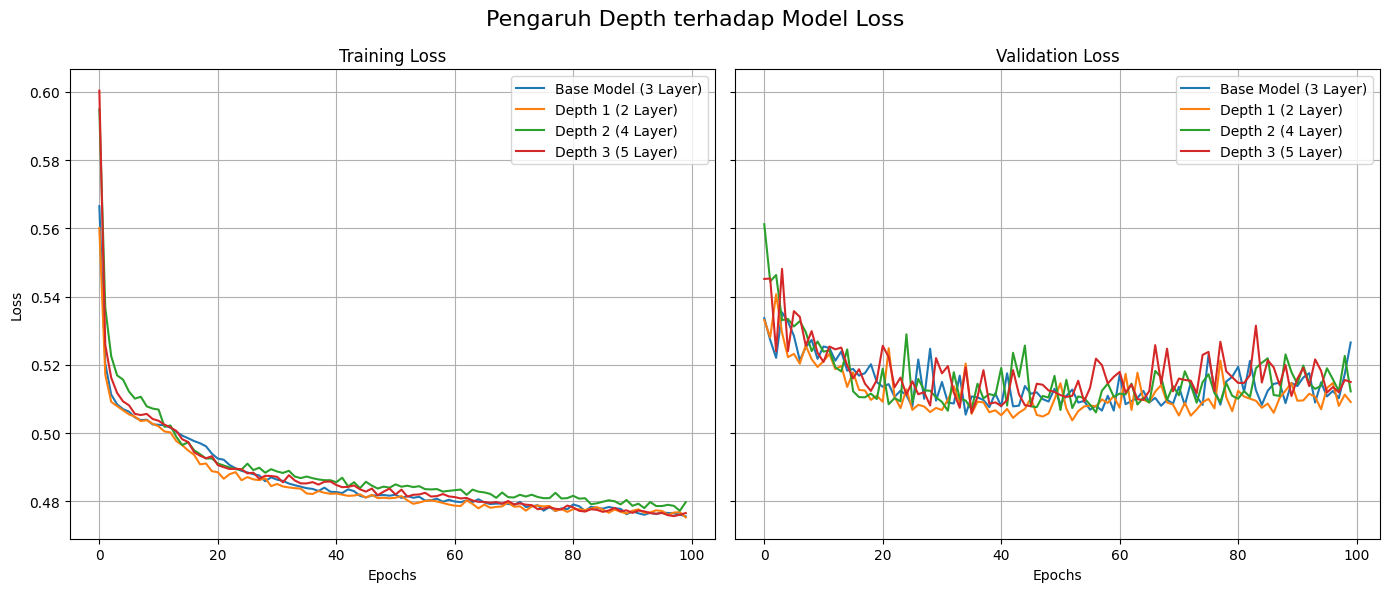

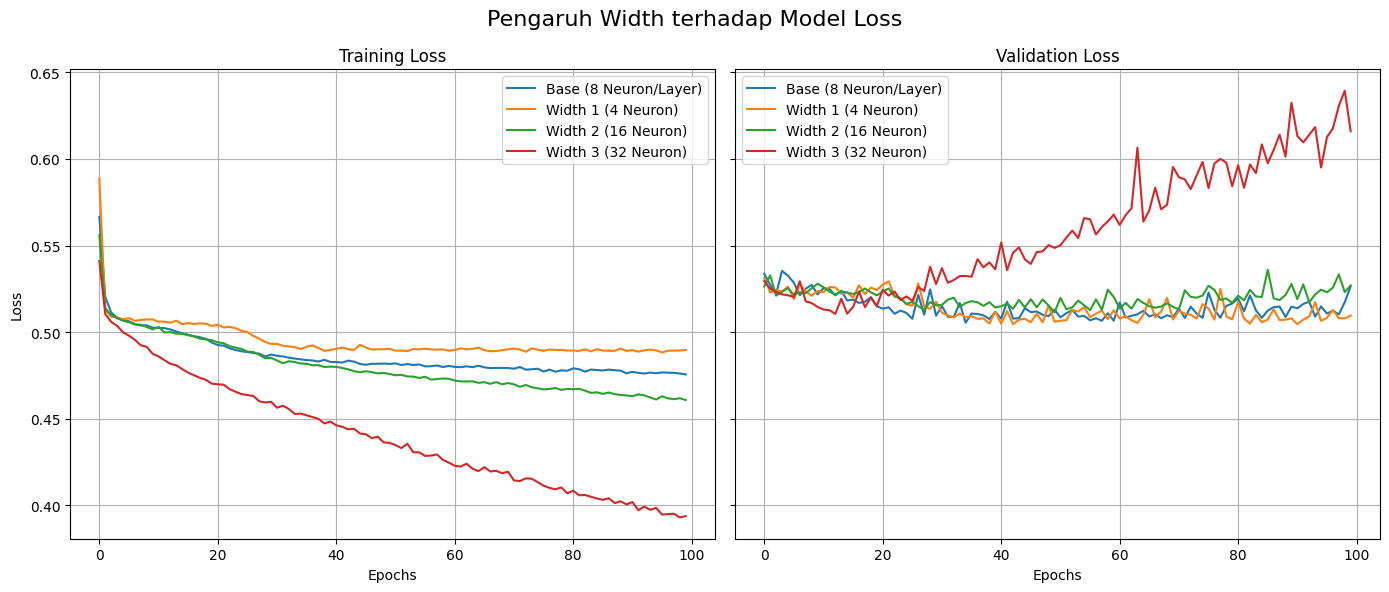

In [40]:
# Depth
histories_depth = [history_base, history_depth1, history_depth2, history_depth3]
titles_depth = ['Base Model (3 Layer)', 'Depth 1 (2 Layer)', 'Depth 2 (4 Layer)', 'Depth 3 (5 Layer)']
plot_loss(histories_depth, titles_depth, 'Pengaruh Depth terhadap Model Loss')

# Width
histories_width = [history_base, history_width1, history_width2, history_width3]
titles_width = ['Base (8 Neuron/Layer)', 'Width 1 (4 Neuron)', 'Width 2 (16 Neuron)', 'Width 3 (32 Neuron)']
plot_loss(histories_width, titles_width, 'Pengaruh Width terhadap Model Loss')

#### 3.4.2 Grafik Pengaruh Fungsi Aktivasi Hidden Layer
[Back to Daftar Isi](#daftar-isi)

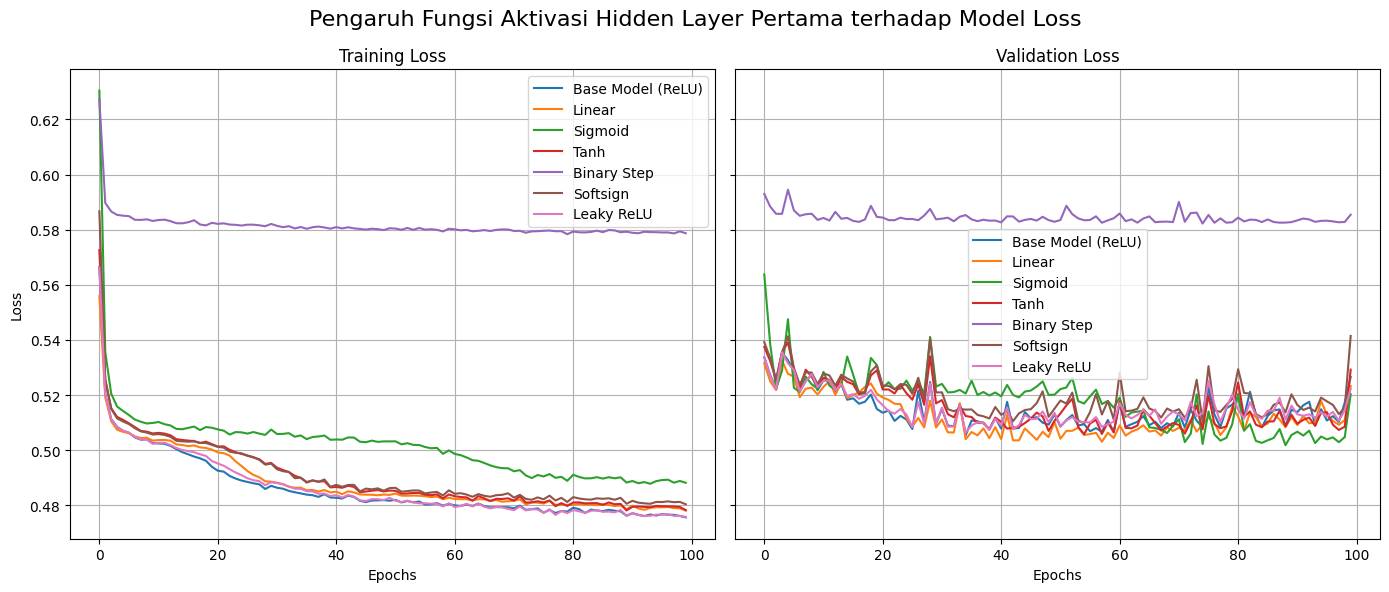

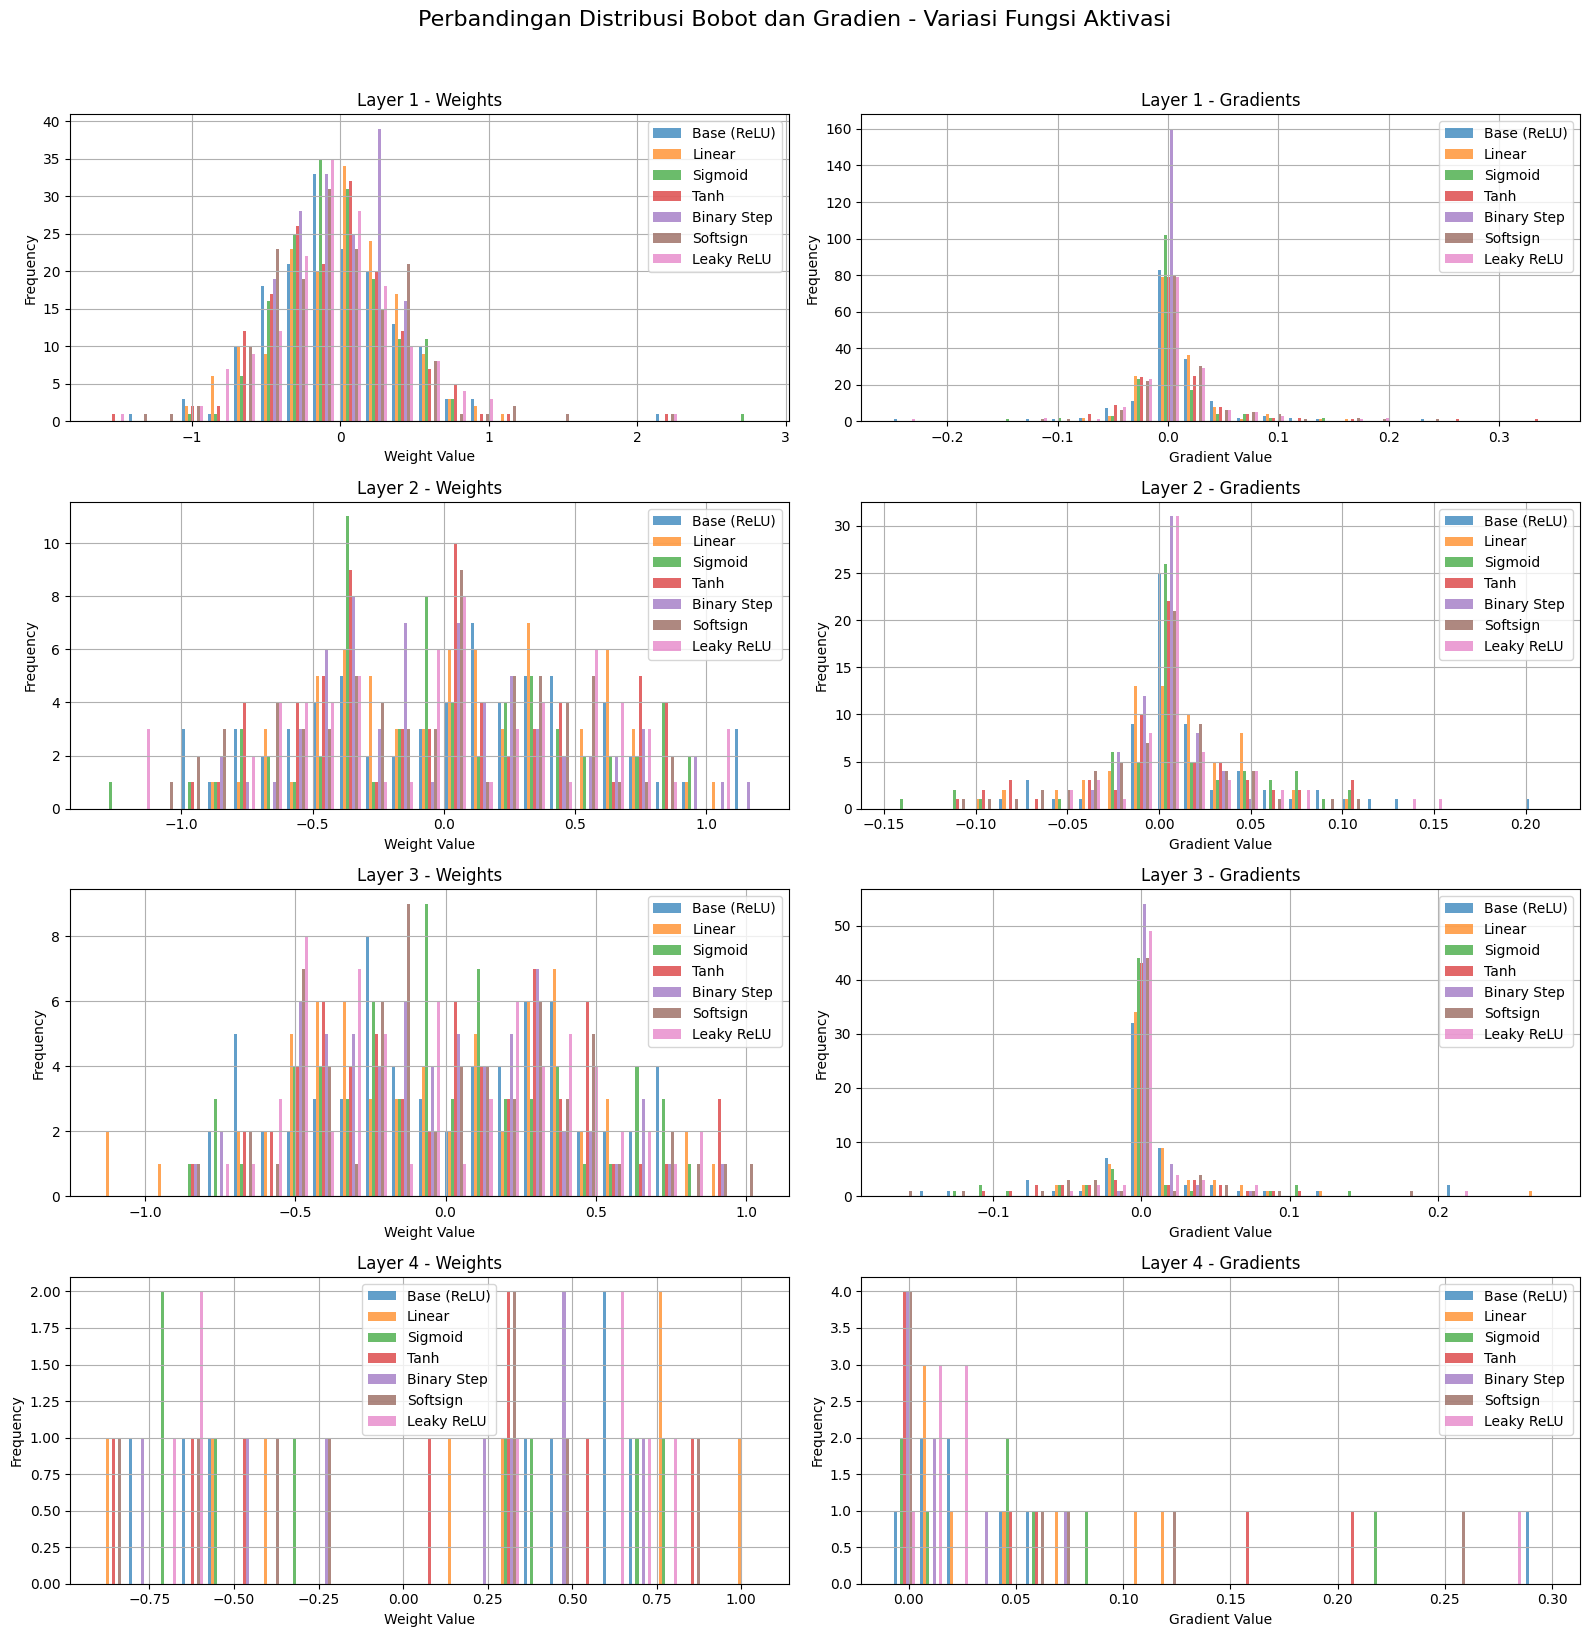

In [41]:
histories_act = [history_base, history_act1, history_act2, history_act3, history_act4, history_act5, history_act6]
titles_act = ['Base Model (ReLU)', 'Linear', 'Sigmoid', 'Tanh', 'Binary Step', 'Softsign', 'Leaky ReLU']

plot_loss(histories_act, titles_act, 'Pengaruh Fungsi Aktivasi Hidden Layer Pertama terhadap Model Loss')

act_models = {
    'Base (ReLU)': ffnn_base_model,
    'Linear': ffnn_fungsiaktivasi_1,
    'Sigmoid': ffnn_fungsiaktivasi_2,
    'Tanh': ffnn_fungsiaktivasi_3,
    'Binary Step': ffnn_fungsiaktivasi_4,
    'Softsign': ffnn_fungsiaktivasi_5,
    'Leaky ReLU': ffnn_fungsiaktivasi_6,
}

plot_weight(act_models, 'Perbandingan Distribusi Bobot dan Gradien - Variasi Fungsi Aktivasi')

#### 3.4.3 Grafik Pengaruh Learning Rate
[Back to Daftar Isi](#daftar-isi)

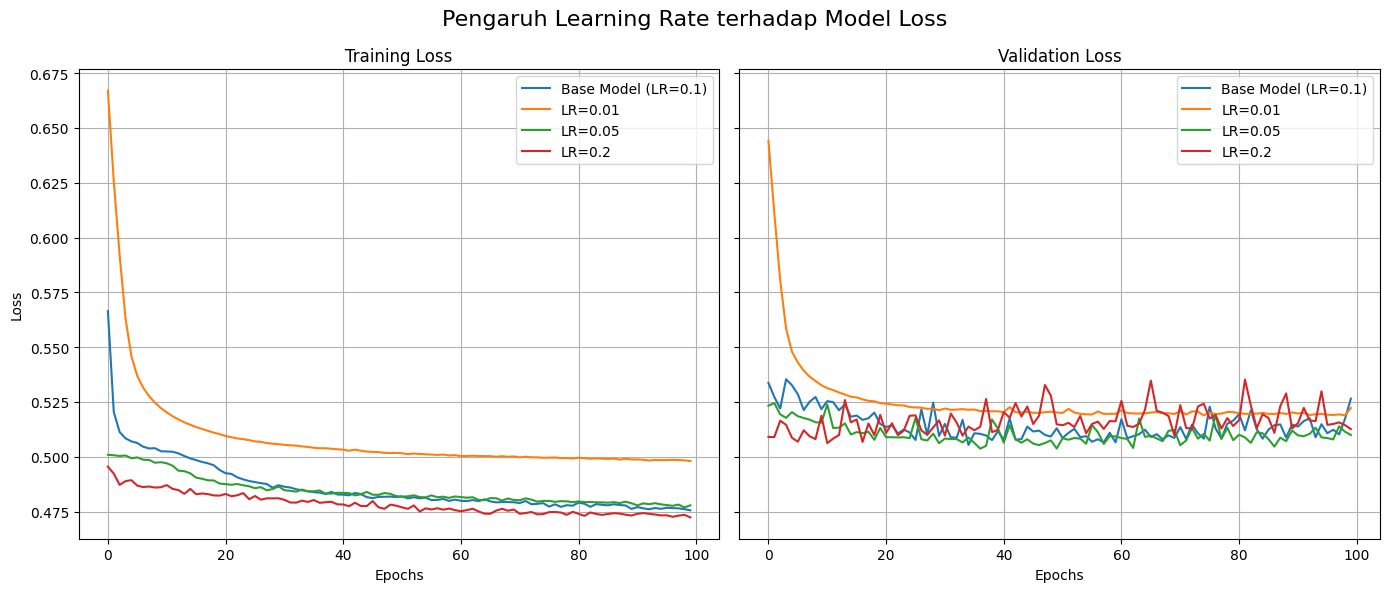

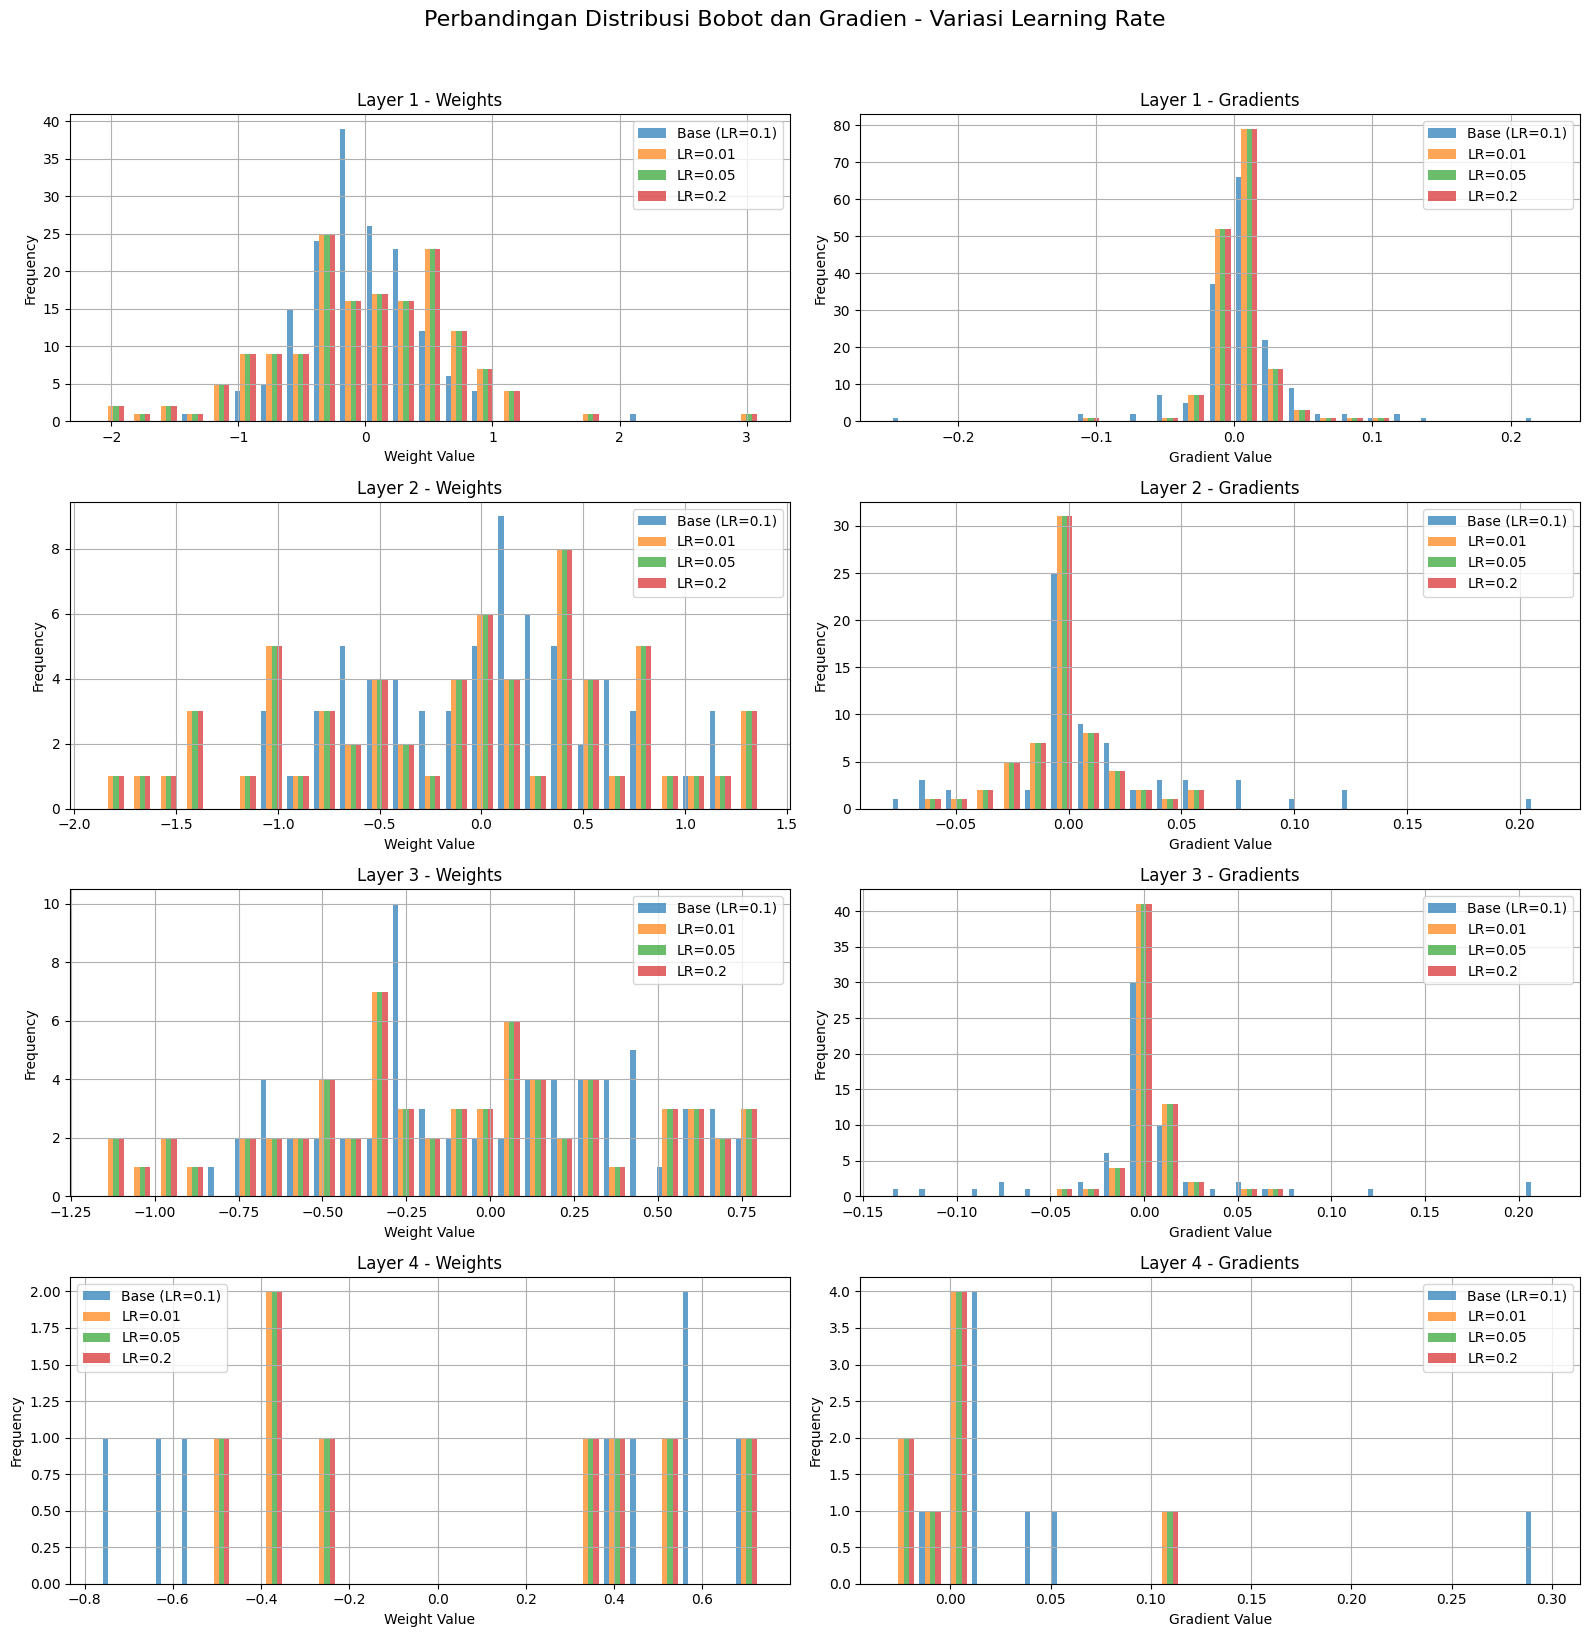

In [42]:
# --- Plot Variasi Learning Rate ---
histories_lr = [history_base, history_lr1, history_lr2, history_lr3]
titles_lr = ['Base Model (LR=0.1)', 'LR=0.01', 'LR=0.05', 'LR=0.2']

plot_loss(histories_lr, titles_lr, 'Pengaruh Learning Rate terhadap Model Loss')

lr_models = {
    'Base (LR=0.1)': ffnn_base_model,
    'LR=0.01': ffnn_lr_1,
    'LR=0.05': ffnn_lr_2,
    'LR=0.2': ffnn_lr_3,
}

plot_weight(lr_models, 'Perbandingan Distribusi Bobot dan Gradien - Variasi Learning Rate')

#### 3.4.4 Grafik Pengaruh Inisialisasi Bobot
[Back to Daftar Isi](#daftar-isi)

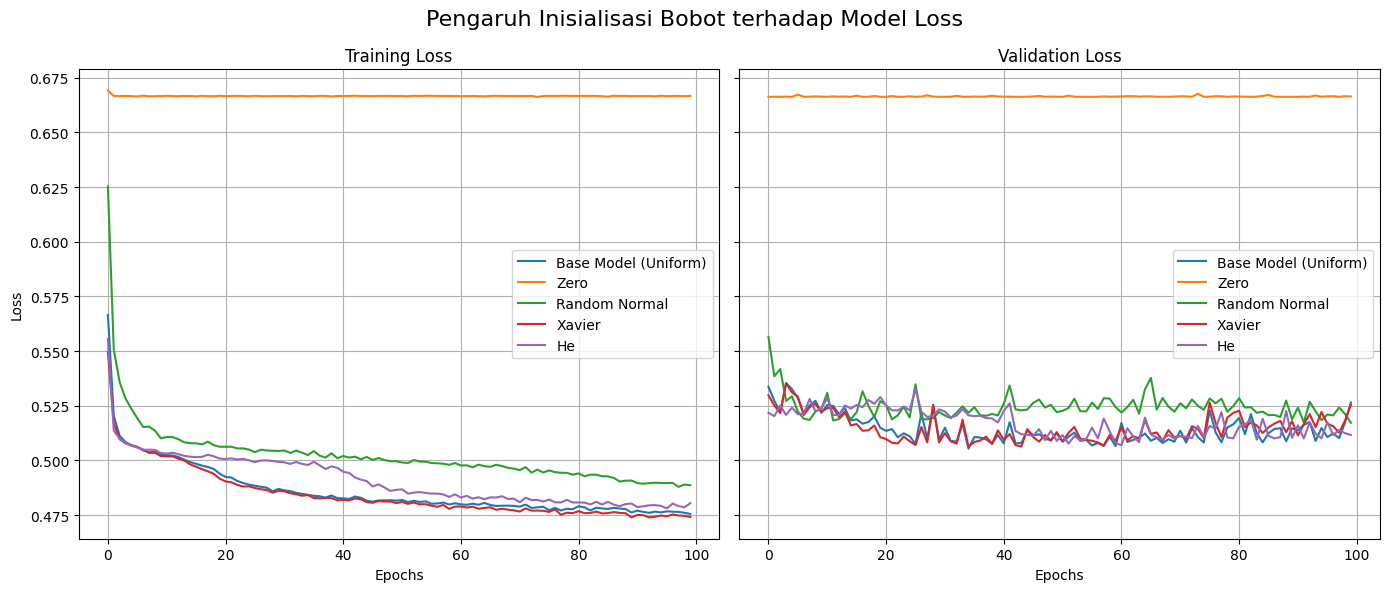

In [43]:
# --- Plot Variasi Inisialisasi Bobot ---
histories_weight = [history_base, history_weight1, history_weight2, history_weight3, history_weight4]
titles_weight = ['Base Model (Uniform)', 'Zero', 'Random Normal', 'Xavier', 'He']

plot_loss(histories_weight, titles_weight, 'Pengaruh Inisialisasi Bobot terhadap Model Loss')

#### 3.4.5 Grafik Pengaruh Regularisasi
[Back to Daftar Isi](#daftar-isi)

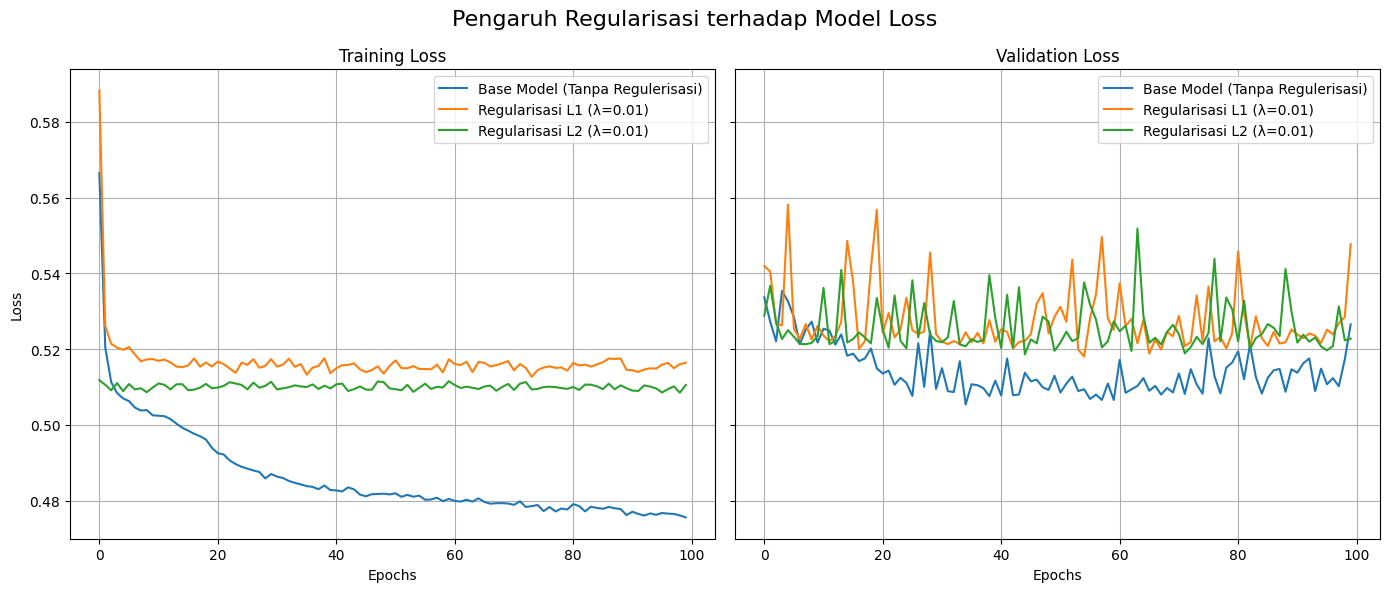

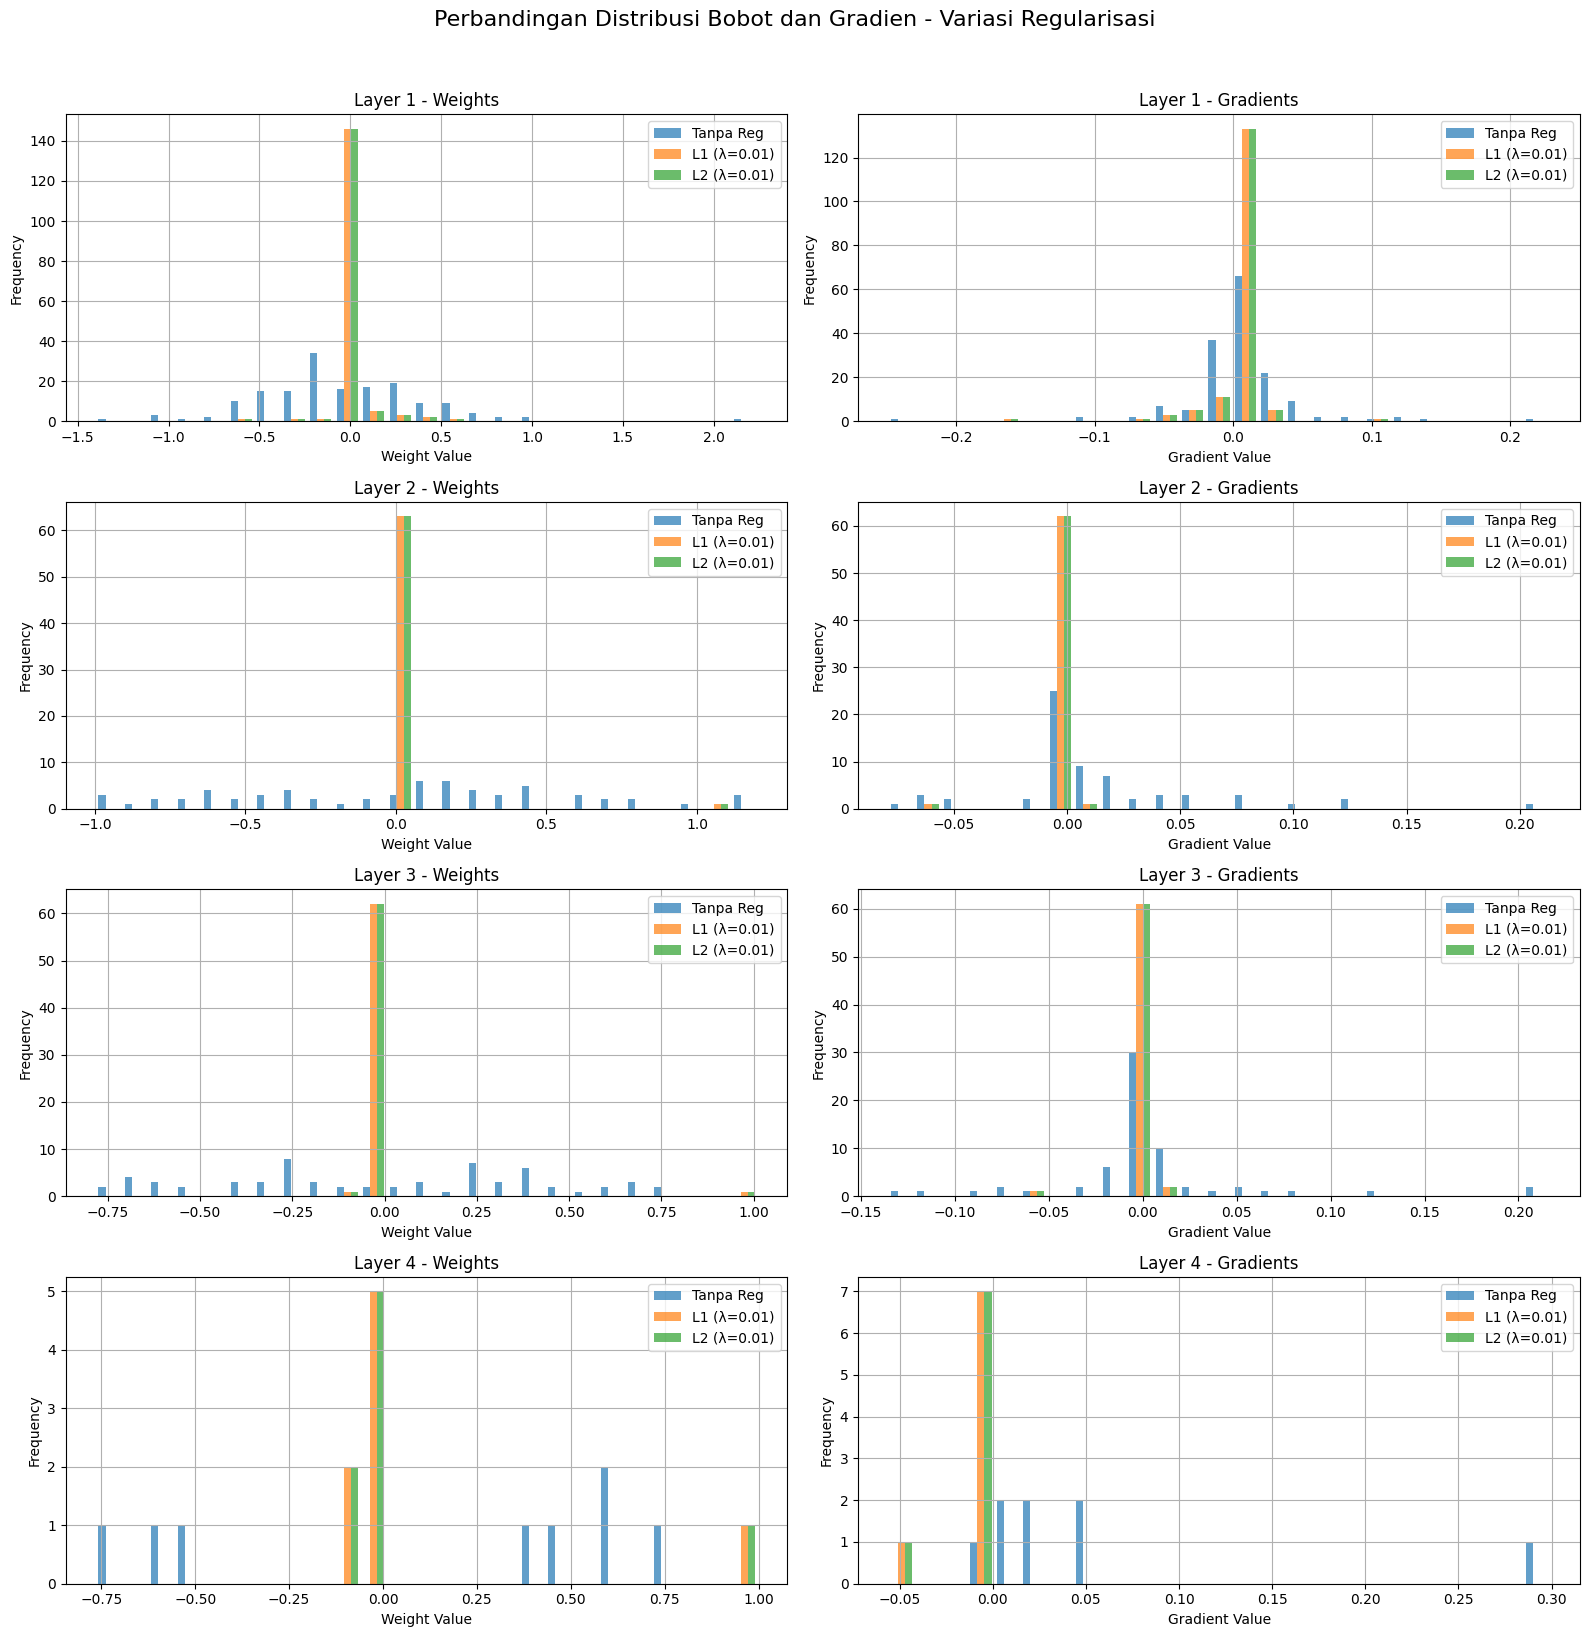

In [44]:
# --- Plot Variasi Regularisasi ---
histories_reg = [history_base, history_reg1, history_reg2]
titles_reg = ['Base Model (Tanpa Regulerisasi)', 'Regularisasi L1 (\u03bb=0.01)', 'Regularisasi L2 (\u03bb=0.01)']

plot_loss(histories_reg, titles_reg, 'Pengaruh Regularisasi terhadap Model Loss')

reg_models = {
    'Tanpa Reg': ffnn_base_model,
    'L1 (λ=0.01)': ffnn_reg_1,
    'L2 (λ=0.01)': ffnn_reg_2,
}

plot_weight(reg_models, 'Perbandingan Distribusi Bobot dan Gradien - Variasi Regularisasi')

### 3.5 Eksperimen Normalisasi RMS
[Back to Daftar Isi](#daftar-isi)

Training Base Model (Tanpa Normalisasi)...
  Base Model (Tanpa Normalisasi) - Data Validation
>>> Validation Macro F1-Score: 0.7193

Training Model dengan RMSNorm...
  Model dengan RMSNorm - Data Validation
>>> Validation Macro F1-Score: 0.7196



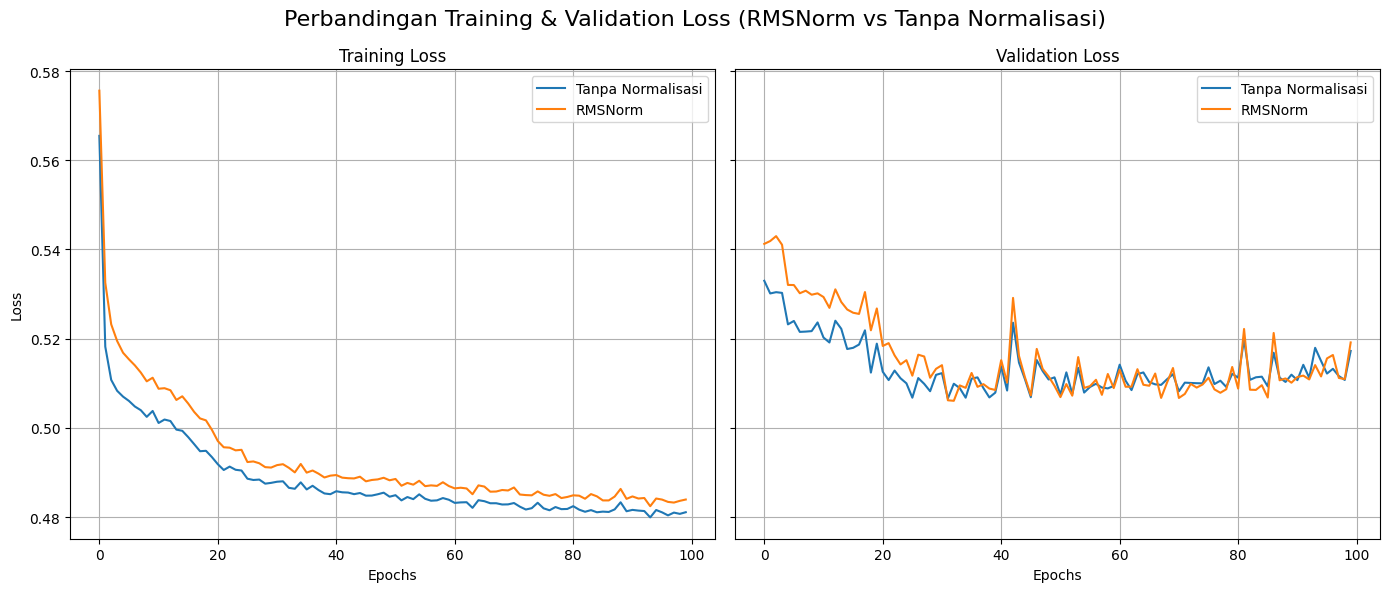

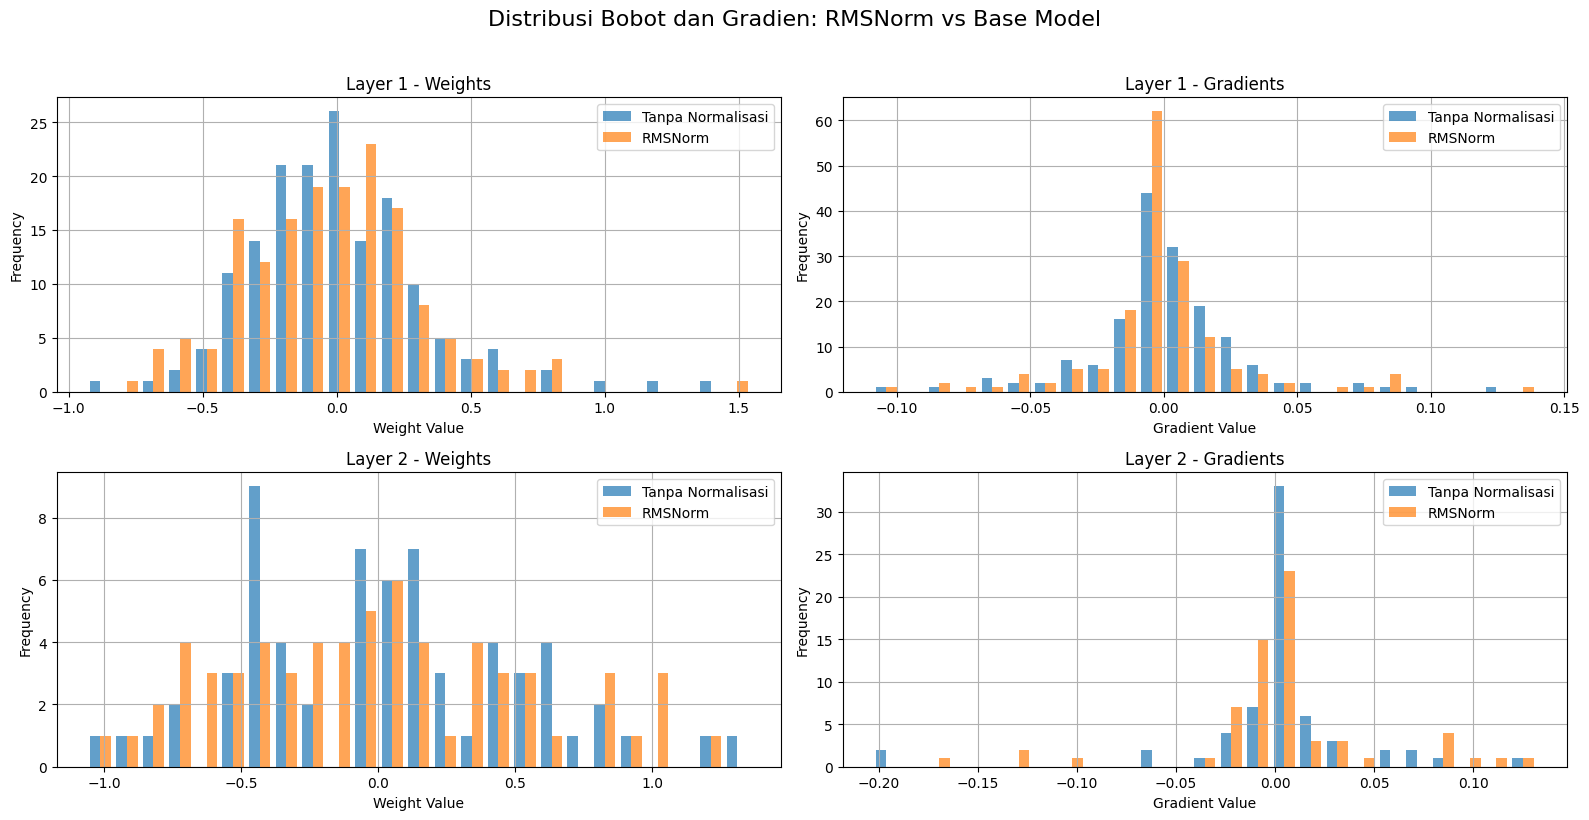

In [45]:
# --- EKSPERIMEN NORMALISASI RMSNORM ---

# 1. Base Model (Tanpa Normalisasi)
ffnn_base_norm = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_base_norm.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='he'))
ffnn_base_norm.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='he'))
ffnn_base_norm.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='he'))

# 2. Model dengan RMSNorm
ffnn_rmsnorm = FFNN(loss_function='binary_cross_entropy', seed=RANDOM_STATE)
ffnn_rmsnorm.add_layer(Layer(input_size=input_dim, output_size=8, activation='relu', init_method='he', norm='rmsnorm'))
ffnn_rmsnorm.add_layer(Layer(input_size=8, output_size=8, activation='relu', init_method='he', norm='rmsnorm'))
ffnn_rmsnorm.add_layer(Layer(input_size=8, output_size=1, activation='sigmoid', init_method='he'))

# Training Base Model
history_base_norm, f1_base_norm = train_and_evaluate_ffnn(
    model=ffnn_base_norm,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="Base Model (Tanpa Normalisasi)",
    epochs=100, learning_rate=0.05, batch_size=32, verbose=0
)

# Training Model dengan RMSNorm
history_rms, f1_rms = train_and_evaluate_ffnn(
    model=ffnn_rmsnorm,
    X_train=X_train_np, y_train=y_train,
    X_val=X_val_np, y_val=y_val,
    model_name="Model dengan RMSNorm",
    epochs=100, learning_rate=0.05, batch_size=32, verbose=0
)

# Visualisasi Loss
plot_loss(
    [history_base_norm, history_rms], 
    ['Tanpa Normalisasi', 'RMSNorm'], 
    'Perbandingan Training & Validation Loss (RMSNorm vs Tanpa Normalisasi)'
)

# Visualisasi Distribusi Bobot dan Gradien
# (Membandingkan layer ke-1 dan ke-2)
model_dict = {
    'Tanpa Normalisasi': ffnn_base_norm,
    'RMSNorm': ffnn_rmsnorm
}
plot_weight(model_dict, "Distribusi Bobot dan Gradien: RMSNorm vs Base Model", layer_indices=[0, 1])

#### 4. Uji Save dan Load

In [46]:
ffnn_base_model.save('model_save.pkl')

model_save = FFNN()
model_save.load('model_save.pkl')

#tes dengan 5 sampel
sampel_x = X_val_np[:5]

pred_asli = ffnn_base_model.forward(sampel_x)
pred_baru = model_save.forward(sampel_x)

if np.array_equal(pred_asli, pred_baru):
    print("Save dan load berhasil \n")

print("Prediksi asli:\n", pred_asli)
print("Prediksi setelah load:\n", pred_baru)



Model saved to model_save.pkl
Model loaded from model_save.pkl
Save dan load berhasil 

Prediksi asli:
 [[0.28178235]
 [0.17591804]
 [0.72416575]
 [0.3843681 ]
 [0.97374636]]
Prediksi setelah load:
 [[0.28178235]
 [0.17591804]
 [0.72416575]
 [0.3843681 ]
 [0.97374636]]
